# Проект: Прогнозирование температуры звезды

## О проекте

В данном ноутбуке представленно несколько наиболее удачных вариантов (каждый родился из своей ветви экспериментов, отличавшихся способом подготовки данных).

### Описание проекта

Мы получили задачу от обсерватории «Небо на ладони»: придумать, как с помощью нейросети определять температуру на поверхности обнаруженных звёзд. Обычно для расчёта температуры учёные пользуются следующими методами:

- Закон смещения Вина.
- Закон Стефана-Больцмана.
- Спектральный анализ.

Каждый из них имеет плюсы и минусы. Обсерватория хочет внедрить технологии машинного обучения для предсказания температуры звёзд, надеясь, что этот метод будет наиболее точным и удобным.

В базе обсерватории есть характеристики уже изученных 240 звёзд.

### Цель проекта

Разработка нейронной сети, которая поможет предсказывать абсолютную температуру на поверхности звезды.

### Описание данных

Наши объекты (звезды) имееют следующие характеристики:

- Относительная светимость `'L/Lo'` — светимость звезды относительно Солнца.
- Относительный радиус `'R/Ro'` — радиус звезды относительно радиуса Солнца.
- Абсолютная звёздная величина `'Mv'` — физическая величина, характеризующая блеск звезды.
- Звёздный цвет (`'white'`, `'red'`, `'blue'`, `'yellow'`, `'yellow-orange'` и др.) — цвет звезды, который определяют на основе спектрального анализа.
- `'Тип звезды'` (Номер, соответствующий типу):
    * Коричневый карлик --	0
    * Красный карлик -- 1
    * Белый карлик	-- 2
    * Звёзды главной последовательности -- 3
    * Сверхгигант -- 4
    * Гипергигант -- 5

- Абсолютная температура `'T(K)'` — температура на поверхности звезды в Кельвинах (целевой признак).

Справочная информация:
- Светимость Солнца (англ. Average Luminosity of Sun)
 L0=3.828⋅10^26 Вт
- Радиус Солнца (англ. Average Radius of Sun)
 R0=6.9551⋅10^8 м

### План проекта

1. Загрузка исходных данных из файла.


2. Проведение исследовательского анализа с использованием графического анализа и выводом:
    - количественных данных,
    - категориальных данных.
    
    
3. Подготовка данных к построению модели (внесение корректировок по результатам исследовательского анализа в случае необходимости) и вывод по итогам:
    - категоризация исходных данных,
    - подготовка обучающей и тестовой выборок,
    - масштабирование количественных данных.
    
    
4. Построение простой модели нейронной сети — baseline:
    - создание класса для задания архитектуры нейронной сети с самостоятельным выбером количества скрытых слоёв, количества нейронов на них, функции активации на скрытых и выходном слоях.
    - испытание и сравнение несколько подобных комбинаций.
    - проведение обучения нейронной сети:
        * создание функции для обучения нейронной сети.
        * проведение обучения модели.
        * построение графика «Факт — Прогноз», где по горизонтальной оси будут отложены условные номера звёзд, а по вертикальной — температура в Кельвинах.
        * вывод по разделу.
        
   
5. Улучшение сети:
    - создание решения с перебором параметров нейросети. Список параметров для перебора должен включать как минимум «dropout» и «размер батча». Архитектуру нейронной сети: количество слоёв, нейронов, вид функции активации — оставьте как в Baseline, чтобы сравнить результат.
    - проведение обучения нейронной сети. Выведение метрики RMSE и построение графика «Факт — прогноз». Метрика RMSE не должна превышать 4500.
    - вывод по разделу с желательным оформлением его в виде таблицы или графика.
    

6. Выводы по проекту:
    - краткое описание результатов каждого типа модели.
    - выводы сравнения двух моделей.

## Загрузка библиотек и установление констант

Загрузим и подключим необходимые для работы над проектом библиотеки, а также зададим константы, которые будем использовать далее.

In [ ]:
# загружаем недостающую библиотеку
!pip install torch

In [ ]:
# подгружаем нейросеть
#!pip install torch==1.10.0+cpu torchvision==0.11.0+cpu torchaudio==0.10.0 -f https://download.pytorch.org/whl/torch_stable.html --user
# дополнительные удобства для работы с ней
# нейронная сеть
# возможно, после установки потребуется перезапустить ядро Jupyter через пункт меню Kernel -> Restart

!pip install skorch # обёртка для PyTorch, предоставляющая удобный интерфейс для работы с нейронными сетями в стиле scikit-learn

In [ ]:
# подгружаем и обновляем необходимые библиотеки
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q

!pip install scikit-learn==1.5.2 -q # обновление для корректной работы некоторых частей кода

# признаки
!pip install phik -q # весы и корреляция

In [ ]:
# подключаем библиотеки
import pandas as pd # работа с данными в формате таблиц
import numpy as np # математические операции и работа с массивами
#from scipy import stats as st # различные вычисления, например, работа со статистикой
#from scipy.stats import randint # используется  некоторых переборах гиперпараметров
import math # расширенная работа с числами
from math import ceil # функция ceil округляет число до ближайшего целого в большую сторону
import time # расчет времени выполнения функций
import random # для контроля над некоторыми рандомами (обеспечение воспроизводимости)
import copy # для создания копии (нейросети)

# расширение дисплея для отображения информации
from IPython.display import display

import tqdm # для визуализации процесса выполнения циклов в виде индикаторной строки.

# "выключаем" красные предупреждения
#import warnings
#warnings.filterwarnings('ignore', category=FutureWarning)

# визуализация данных
import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков

# корреляция
#import phik # дублирование для иных проектов и платформ (может не требоваться в данном проекте, тк загружали ее выше)
from phik import phik_matrix # вариант матрицы корреляции
from phik.report import plot_correlation_matrix # ее отрисовка

# подготовка данных
from sklearn.model_selection import(
    train_test_split, # для разбивки на выборки для МО
    KFold, # для настройки параметров кросс-валидации
    GridSearchCV, # для перебора параметров
    ParameterGrid # тоже перебор параметров
    )
from sklearn.utils import shuffle # перемешивание данных для уравновешивания их в разных выборках
from sklearn.preprocessing import(
# кодировка категориальных признаков
    OneHotEncoder, # номинальные
    OrdinalEncoder, # ранговые
    StandardScaler # масштабирование количественных
    )
from sklearn.base import BaseEstimator # для работы с некоторыми классами

# метрики моделей
from sklearn.metrics import (
    mean_squared_error, # MSE(среднеквадратичная ошибка) и RMSE(ее корень), не работает с Optuna
    make_scorer) # создание пользовательской метрики (для некоторыx вариантов реализации RMSE)

# инструменты для работы с пайплайнами
from sklearn.pipeline import Pipeline # пайплайны
from sklearn.compose import ColumnTransformer # помогает работать с данными разного типа в одном наборе

# установка необходимых пакетов для нейросети
import torch # основная библиотека
import torch.nn as nn # модуль, который содержит классы и функции для построения нейронных сетей
from torch.utils.data import Dataset, DataLoader # для удобства работы с некотороми вариантами обучения

from skorch import NeuralNetRegressor # настройка параметров обучения нейронных сетей в процессе решения задач регресии
from skorch.callbacks import Callback # обратный вызов для дополнительных настроек

In [ ]:
# задаем настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format ='{:,.2f}'.format
sns.set_theme(style='whitegrid', palette='pastel')
sns.set_context(
    'notebook',
    rc={
        'font.size':12,
        'axes.titlesize':16,
        'axes.labelsize':12,
        'legend.fontsize':12,
        'figure.figsize':(14, 7)
    }
)

# отключаем предупреждения:
# когда используется функционал, который в будущем может измениться или устареть
#warnings.simplefilter(action='ignore', category=FutureWarning)
# когда выполняется присваивание значений через несколько индексов или атрибутов,
# и библиотека не может однозначно определить, является ли это намеренным действием или потенциальной ошибкой
#pd.options.mode.chained_assignment = None

# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# задаем константы
# для фиксации объектов тренировочной и тестовой выборок
RANDOM_STATE = 42
# для пропорционального разделения датасета на тренировочную и тестовую выборки
TEST_SIZE = 0.3

# Установка seed'ов для воспроизводимости
SEED = 42 # кое-где вместо привычного RANDOM_STATE

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True # делает CUDA операции детерминированными
torch.backends.cudnn.benchmark = False # отключаем автотюнинг для воспроизводимости

In [ ]:
# cоздаем пользовательскую метрику RMSE
# функция для получения RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
# собственная метрика
rmse_scorer = make_scorer(rmse, greater_is_better=False)  # greater_is_better=False, так как RMSE нужно минимизировать

**Вывод**

Необходимые для работы библиотеки подключены, некоторые константы заданы, стиль отображения настроен.

## Загрузка данных

Создадим функцию для краткого обзора и описания наших данных.

In [ ]:
# функция для краткого обзора и описания
def first_discr(data, titl, num):

  print(color.BLUE + color.BOLD + f"\n === Первые {num} строк в {titl}: ===\n" + color.END)
  display(data.head(num))

  print(color.BLUE + color.BOLD + f"\n === Общая информация о данных в {titl}: ===\n" + color.END)
  display(data.info())

  print(color.BLUE + color.BOLD + f"\n === Размер датасета {titl}:===\n" + color.END + f"    {data.shape}\n")

  return

Теперь загрузим наши данные и применим к ним ранее созданную функцию.

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка датасета
try:
    stars = pd.read_csv('/datasets/6_class.csv')
except:
    stars = pd.read_csv('https://адрес_удален/datasets/6_class.csv')

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(stars,'stars', 30)


 === Первые 30 строк в stars: ===



,Unnamed: 0,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,0,3068,0.00,0.17,16.12,0,Red
1,1,3042,0.00,0.15,16.60,0,Red
2,2,2600,0.00,0.10,18.70,0,Red
3,3,2800,0.00,0.16,16.65,0,Red
4,4,1939,0.00,0.10,20.06,0,Red
5,5,2840,0.00,0.11,16.98,0,Red
6,6,2637,0.00,0.13,17.22,0,Red
7,7,2600,0.00,0.10,17.40,0,Red
8,8,2650,0.00,0.11,17.45,0,Red
9,9,2700,0.00,0.13,16.05,0,Red



 === Общая информация о данных в stars: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              240 non-null    int64  
 1   Temperature (K)         240 non-null    int64  
 2   Luminosity(L/Lo)        240 non-null    float64
 3   Radius(R/Ro)            240 non-null    float64
 4   Absolute magnitude(Mv)  240 non-null    float64
 5   Star type               240 non-null    int64  
 6   Star color              240 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 13.2+ KB


None


 === Размер датасета stars:===
    (240, 7)



Данные в датасете соответствуют заявленным.

Имена столбцов не соответствуют правилам хорошего тона и требуют переименования, чем мы займемся далее.

Столбец `'Unnamed: 0 '`, вероятно, раньше мог содержать имя звезды, но потерял его в ходе обезличивания данных, а теперь дублирует индекс (либо это изначальное задублирование индексов при некорректном переносе/сохранении данных на каком-либо этапе). То есть от него можно потенциально избавиться.

Типы данных в столбцах соответстуют содержимому. Хотя, теоретически, столбцам с категориальными данными можно было бы в будущем присвоить тип данных `'category'` вместо `'object'` или `'int'`, но пока обойдемся без этого.

Явных пропусков не обнаружено.

**Выводы**

- Данные в датасете соответствуют заявленным.
- Имена столбцов не соответствуют правилам хорошего тона и требуют переименования.
- Столбец `'Unnamed: 0 '` является дублем индекса, поэтому от него можно избавиться.
- Типы данных в столбцах соответстуют содержимому (но потенциально можно преобразовать часть из них в `'category'`).
- Явных пропусков не обнаружено.

<div class="alert alert-success">
<b>👍 Успех:</b> Датасет загружен и просмотрен!
</div>

## Предобработка и анализ данных

### Предподготовка данных

#### Перезагрузка

Можно переименовать столбцы уже загруженного датасета и удалить из него неинформативный столбец. Но мы перезагрузим данные заново, с учетом ранее выявленных проблем.

In [ ]:
# создание словаря с новыми именами столбцов
new_column_names = {
    'Temperature (K)': 'temperature',
    'Luminosity(L/Lo)': 'luminosity',
    'Radius(R/Ro)': 'radius',
    'Absolute magnitude(Mv)': 'magnitude_abs',
    'Star type': 'type',
    'Star color': 'color',
}

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка датасета
try:
    stars = pd.read_csv('/datasets/6_class.csv', index_col=0).rename(columns=new_column_names)
except:
    stars = pd.read_csv('https://адрес_удален/datasets/6_class.csv', index_col=0).rename(columns=new_column_names)

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(stars,'stars', 30)


 === Первые 30 строк в stars: ===



,temperature,luminosity,radius,magnitude_abs,type,color
0,3068,0.00,0.17,16.12,0,Red
1,3042,0.00,0.15,16.60,0,Red
2,2600,0.00,0.10,18.70,0,Red
3,2800,0.00,0.16,16.65,0,Red
4,1939,0.00,0.10,20.06,0,Red
5,2840,0.00,0.11,16.98,0,Red
6,2637,0.00,0.13,17.22,0,Red
7,2600,0.00,0.10,17.40,0,Red
8,2650,0.00,0.11,17.45,0,Red
9,2700,0.00,0.13,16.05,0,Red



 === Общая информация о данных в stars: ===

<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    240 non-null    int64  
 1   luminosity     240 non-null    float64
 2   radius         240 non-null    float64
 3   magnitude_abs  240 non-null    float64
 4   type           240 non-null    int64  
 5   color          240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB


None


 === Размер датасета stars:===
    (240, 6)



#### Систематизация по типу данных

Для удобства работы с данными систематизируем столбцы по типу данных содержимого.

In [ ]:
# функция для разделения колонок по типу содержимого
def num_cat_sort(df):

    cat_col_names = [] # список имен категориальных
    num_col_names = [] # список имен числовых столбцов

    col_list = df.columns # список имен всех колонок

    try:
        for col in col_list:
            if df[col].dtypes == 'int' or df[col].dtypes == 'float':
                num_col_names.append(col)

            elif df[col].dtypes == 'object' or df[col].dtypes == 'category':
                cat_col_names.append(col)

            else:
                pass
    except:
        pass

#    return  col_list, num_col_names, cat_col_names
    return num_col_names, cat_col_names

In [ ]:
# получаем списки имен столбцов
num_col_names, cat_col_names = num_cat_sort(stars)

In [ ]:
# проверка содержимого 1
num_col_names

['temperature', 'luminosity', 'radius', 'magnitude_abs', 'type']

In [ ]:
# проверка содержимого 2
cat_col_names

['color']

Столбцы разделилились верно согласно заявленным типам данных, но не совсем верно - согласно истинному содержимому. Поэтому немного исправим их.

In [ ]:
# изменяем список числовых
num_col_names.remove('type') # удаляем
num_col_names # проверяем

['temperature', 'luminosity', 'radius', 'magnitude_abs']

Температура, которая является целевым признаком, пока останется в списке числовых признаков для удобства дальнейшего исследовательского анализа и будет исключена перед началом работы с нейронной сетью.

In [ ]:
# изменяем список категориальных
cat_col_names.append('type') # добавляем
cat_col_names # проверяем

['color', 'type']

Теперь столбцы разделены верно согласно своему содержимому.

#### Дубликаты и неявные пропуски

Посчитаем явные дубликаты в наших данных.

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество явных дубликатов: "+ color.END + f"{stars.duplicated().sum()}")

Количество явных дубликатов: 0


Явные дубликаты отсутствуют. Но даже если бы они и были, ввиду малого количества параметров нельзя было бы однозначно утверждать, что это действительно истинные дубликаты.

Теперь поищем скрытые дубликаты среди значений.

In [ ]:
# функция для подсчета и вывода уникальных значений:
def uniq(data, col_name):
    for col in col_name:
        print(color.BLUE + color.BOLD + f"Количество уникальных значений в столбце {col}: "
              + color.END + f"{len(data[col].unique())}") # считаем
        try:
            print(color.BLUE + color.BOLD + f"Уникальные значения столбца {col}: "
               + color.END + '\n' + f"{data[col].sort_values().unique()}\n") # смотрим с сортировкой
        except:
            print(color.BLUE + color.BOLD + f"Уникальные значения столбца {col}: "
               + color.END + '\n' + f"{data[col].unique()}\n") # смотрим без сортировки

In [ ]:
# применяем функцию uniq
uniq(stars, cat_col_names)

Количество уникальных значений в столбце color: 19
Уникальные значения столбца color: 
['Blue' 'Blue ' 'Blue White' 'Blue white' 'Blue white ' 'Blue-White'
 'Blue-white' 'Orange' 'Orange-Red' 'Pale yellow orange' 'Red' 'White'
 'White-Yellow' 'Whitish' 'Yellowish' 'Yellowish White' 'white'
 'yellow-white' 'yellowish']

Количество уникальных значений в столбце type: 6
Уникальные значения столбца type: 
[0 1 2 3 4 5]



Мы можем наблюдать скрытые дубликаты: одни и те же цвета имеют разные написания.

Немного упорядочим наименования цветов.

In [ ]:
# удаляем пробелы в начале и конце, приводим к нижнему регистру, заменяем дефис на пробел
stars.color = stars.color.str.strip().str.lower().str.replace('-', ' ')

In [ ]:
# применяем функцию uniq
uniq(stars, cat_col_names)

Количество уникальных значений в столбце color: 12
Уникальные значения столбца color: 
['blue' 'blue white' 'orange' 'orange red' 'pale yellow orange' 'red'
 'white' 'white yellow' 'whitish' 'yellow white' 'yellowish'
 'yellowish white']

Количество уникальных значений в столбце type: 6
Уникальные значения столбца type: 
[0 1 2 3 4 5]



Дубликатов стало меньше. Однако все еще есть: например, `'whitish'` и `'white'`. Также, согласно открытым источникам [1](https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B5%D0%BA%D1%82%D1%80%D0%B0%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%B7%D0%B2%D1%91%D0%B7%D0%B4), [2](https://spacegid.com/spektralnyie-klassyi-zvezd.html), [3](https://habr.com/ru/companies/ua-hosting/articles/411657/) и [4](https://autosprite.ru/foto/pozdnie-spektralniye-klassiy), спектральная классификация звёзд имеет 7 классов. И хотя мы не имеем возможности уточнить это у заказчика, но можем предполагать, что он опирался именно на нее, а потому можем упорядочить наши данные согласно современным стандартам, принятым в астрономии.

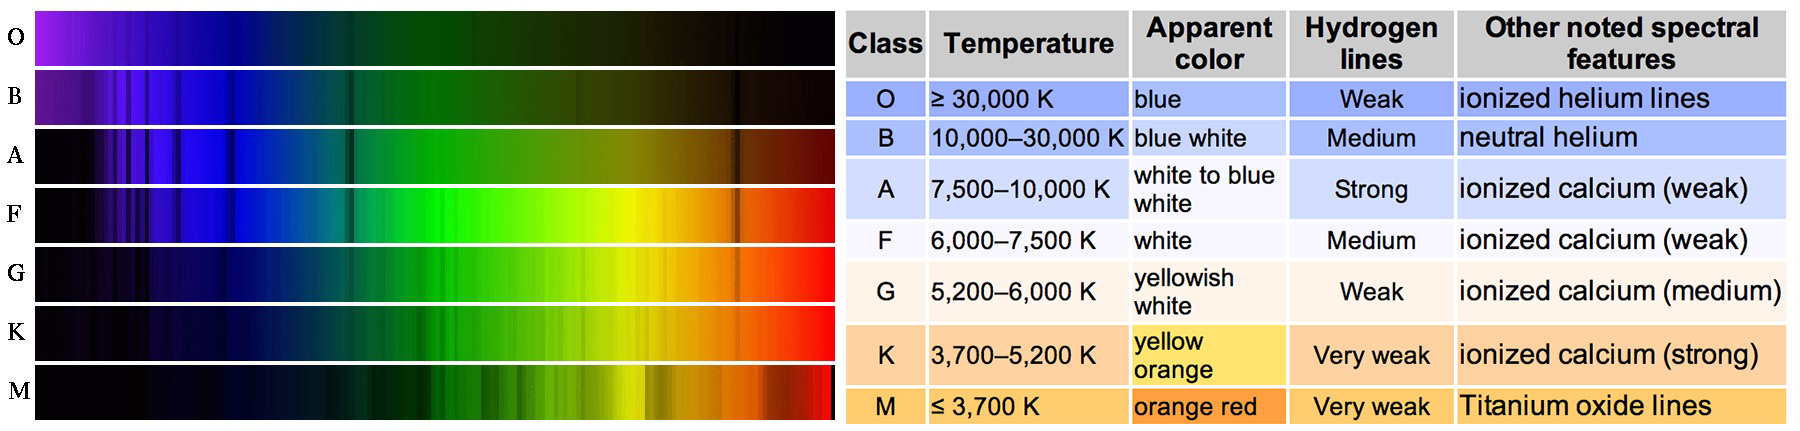![u1on9ybwc_m6wfik7ds1cw1f1cy.jpeg](attachment:u1on9ybwc_m6wfik7ds1cw1f1cy.jpeg) (*пример, изображение из источника 3*)

![slide-3.jpg](https://74foto.ru/800/600/http/cf2.ppt-online.org/files2/slide/3/3PZMUBdsuoqYFHe9gSbwWv7nJkatIORhNQic5ymVGC/slide-3.jpg)
(*пример, изображение из источника 4*)

Также исходя из этих источников мы заранее можем предположить связь температуры, цвета и абсолютной звездной величины для звезд.

Теоретически, мы можем заменить цвета буквами согласно принятой классификации, но пока не будем использовать ее для удобства восприятия.

Избавимся от однозначных дубликатов без применения вышеобозначенных источников и немного упростим наименования.

In [ ]:
# замена цветов
try:
    stars['color'] = stars['color'].replace({
        'whitish': 'white',
        'pale yellow orange': 'yellow orange',
        'yellowish':'yellow'
    }).replace(['white yellow','yellow white'], 'yellowish white')
    print('Выполнена замена')
except:
    print('Замена не выполнена')

Выполнена замена


In [ ]:
# применяем функцию uniq
uniq(stars, cat_col_names)

Количество уникальных значений в столбце color: 9
Уникальные значения столбца color: 
['blue' 'blue white' 'orange' 'orange red' 'red' 'white' 'yellow'
 'yellow orange' 'yellowish white']

Количество уникальных значений в столбце type: 6
Уникальные значения столбца type: 
[0 1 2 3 4 5]



Дубликатов стало меньше. Но классов у нас все равно больше, чем "положено". Чтобы не изменять оригинальные данные, создадим новый столбец, где укажем цветовой класс.

![123.jpg](http://spacegid.com/wp-content/uploads/2015/12/123.jpg) (*пример, изображение из источника 2*)

Перед эти посмотрим на звезды с цветом `'orange'`, чтобы правильно их классифицировать.

In [ ]:
# смотрим на звезды оранжевого цвета
stars[stars['color'] == 'orange']

,temperature,luminosity,radius,magnitude_abs,type,color
53,3749,"550,000.00","1,648.00",-8.05,5,orange
172,4287,"630,000.00","1,315.00",-9.20,5,orange


Судя по температуре, данные звезды относятся к типу `'K'`.

Также мы можем взглянуть распределение данных по цветам.

In [ ]:
# группируем по цвету
stars['color'].value_counts()

red                112
blue                56
blue white          41
yellowish white     12
white               12
yellow               3
orange               2
orange red           1
yellow orange        1
Name: color, dtype: int64

Как мы видим, некоторые из вариантов представлены совсем небольшим количеством объектов. Поэтому тем более правильнее будет группы укрупнить. Но так как температуры звезд в разных классах существенно отличаются, сливать несколько классов воедино мы все же не будем, обойдясь теми семью, что приняты.

In [ ]:
# функция для заполнения нового столбца
def color_cl(color):
    try:
        if color == 'blue':
            return 'O'
        elif color == 'blue white':
            return 'B'
        elif color == 'white':
            return 'A'
        elif color == 'yellowish white':
            return 'F'
        elif color == 'yellow':
            return 'G'
        elif color == 'yellow orange' or (color == 'orange') :
            return 'K'
        elif color == 'orange red' or (color == 'red'):
            return 'M'
        else:
            return 'unk'
    except:
        pass

In [ ]:
# применяем функцию
stars['color_class'] = stars['color'].apply(color_cl)

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(stars,'stars', 30)


 === Первые 30 строк в stars: ===



,temperature,luminosity,radius,magnitude_abs,type,color,color_class
0,3068,0.00,0.17,16.12,0,red,M
1,3042,0.00,0.15,16.60,0,red,M
2,2600,0.00,0.10,18.70,0,red,M
3,2800,0.00,0.16,16.65,0,red,M
4,1939,0.00,0.10,20.06,0,red,M
5,2840,0.00,0.11,16.98,0,red,M
6,2637,0.00,0.13,17.22,0,red,M
7,2600,0.00,0.10,17.40,0,red,M
8,2650,0.00,0.11,17.45,0,red,M
9,2700,0.00,0.13,16.05,0,red,M



 === Общая информация о данных в stars: ===

<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    240 non-null    int64  
 1   luminosity     240 non-null    float64
 2   radius         240 non-null    float64
 3   magnitude_abs  240 non-null    float64
 4   type           240 non-null    int64  
 5   color          240 non-null    object 
 6   color_class    240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 15.0+ KB


None


 === Размер датасета stars:===
    (240, 7)



Классификация звезд по цвету прошла успешно.

Также, в теории, мы могли бы задать новому столбцу тип данных `'category'`, и даже назначить иерархию (ведь они отличаются по длине волны; то есть на самом деле больше подходил бы кодировщик ORD, чем OHE). Но попробуем пока обойтись без этого.

Потенциально, ввиду высокой корреляции, столбец-исходник будет исключен из исследования. Поэтому исправим список категориальных столбцов.

In [ ]:
# изменяем список
cat_col_names.remove('color') # удаляем
cat_col_names.append('color_class') # добавляем
cat_col_names # проверяем

['type', 'color_class']

In [ ]:
# применяем функцию uniq
uniq(stars, cat_col_names)

Количество уникальных значений в столбце type: 6
Уникальные значения столбца type: 
[0 1 2 3 4 5]

Количество уникальных значений в столбце color_class: 7
Уникальные значения столбца color_class: 
['A' 'B' 'F' 'G' 'K' 'M' 'O']



От дубликатов в важных для исследования столбцах мы избавились.

Неявных пропусков в категориальных столбцах мы не обнаружили.

**Выводы**

- Перезагрузили данные с учетом обнаруженных проблем.
- Систематизировали столбцы согласно содержимому.
- Избавились от неявных дубликатов и упорядочили один из категориальных признаков в специальносозданном столбце.
- Явные дубликаты и неявные пропуски обнаржены не были.

### Исследовательский анализ данных

#### Категориальные данные

Преобразуем цветовой класс в тип данных `'category'` и зададим порядок (от большей температуры - к меньшей, от голубого - к красному)

In [ ]:
# изменение типа данных и задание иерархии
stars['color_class'] = stars['color_class'].astype('category').cat.set_categories(['M', 'K', 'G', 'F', 'A', 'B','O'],
                                                                                  ordered=True)

In [ ]:
# проверка
stars['color_class'].dtypes

CategoricalDtype(categories=['M', 'K', 'G', 'F', 'A', 'B', 'O'], ordered=True)

Посмотрим, какую долю данных у нас занимают звезды разных цветов.



In [ ]:
# группируем по цветовому классу
stars['color_class'].value_counts()

M    113
O     56
B     41
F     12
A     12
K      3
G      3
Name: color_class, dtype: int64

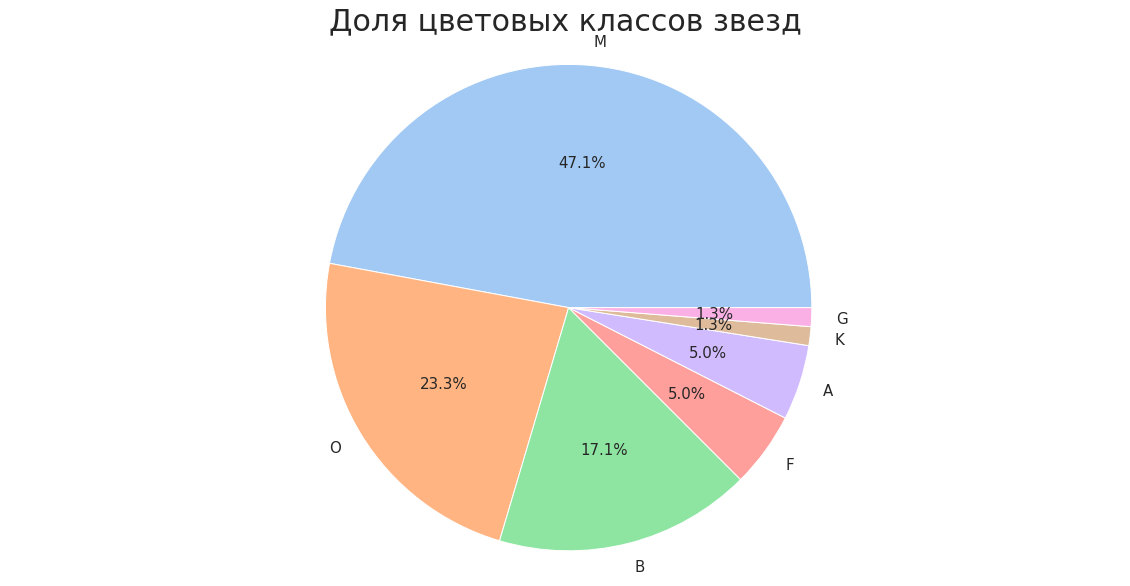

In [ ]:
# визуализируем
stars['color_class'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доля цветовых классов звезд', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Некоторые классы слишком малы (с другой стороны - сам датасет у нас тоже невелик). Но объединять их с другим все-таки не совсем корректно, так как разность по температуре у них существенная. Удалять - тем более (тогда сеть вовсе не научится делать предсказания для них). Можно попробовать обойтись имеющимися данными, а в случае неудовлетворительного результата применить аугументацию.

In [ ]:
# группируем по типу
stars['type'].value_counts()

0    40
1    40
2    40
3    40
4    40
5    40
Name: type, dtype: int64

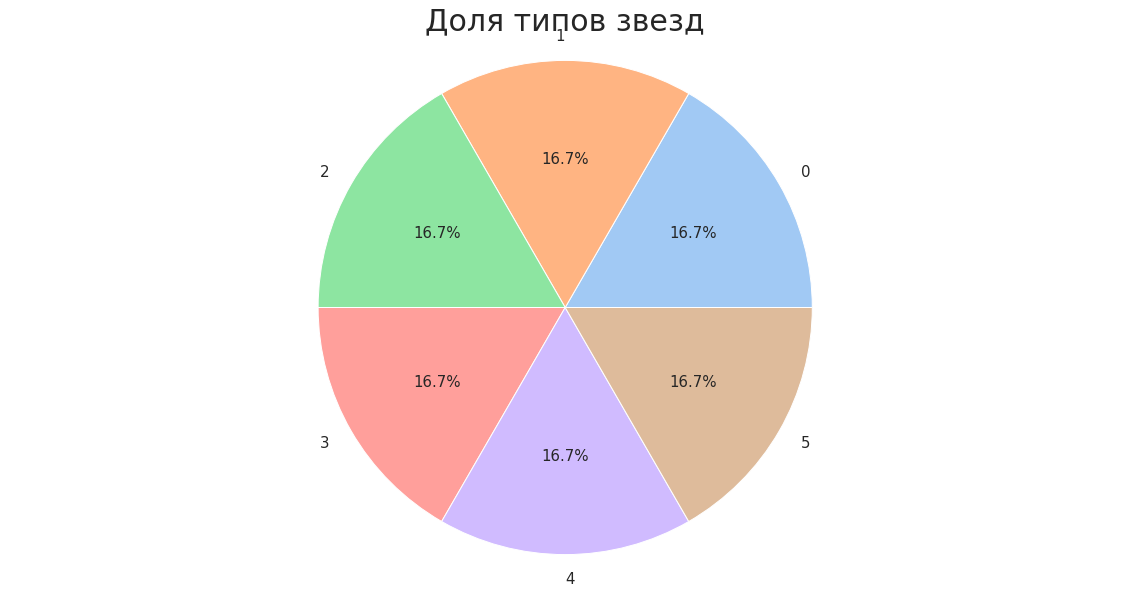

In [ ]:
# визуализируем
stars['type'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доля типов звезд', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

А вот тут мы наблюдаем хорошую равномерную выборку.

#### Числовые данные

Посмотрим теперь на числовые данные (которых большинство) нашего датасета.

##### Общий обзор

In [ ]:
# общее числовое описание
stars[num_col_names].describe()

,temperature,luminosity,radius,magnitude_abs
count,240.00,240.00,240.00,240.00
mean,"10,497.46","107,188.36",237.16,4.38
std,"9,552.43","179,432.24",517.16,10.53
min,"1,939.00",0.00,0.01,-11.92
25%,"3,344.25",0.00,0.10,-6.23
50%,"5,776.00",0.07,0.76,8.31
75%,"15,055.50","198,050.00",42.75,13.70
max,"40,000.00","849,420.00","1,948.50",20.06


Уже сейчас можно подозревать выбросы и аномалии у значений температуры и относительной светимости. Как же обстоит на самом деле - узнаем далее.

##### По столбцам

In [ ]:
# создание функции для будущего описания числовых недискретных признаков
def discr_num(col_data, title, x_label):
    # Создание графиков: гистограмма и диаграмма размаха
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

    # Гистограмма
    sns.histplot(data=col_data, bins=50, kde=True, ax=axs[0])
    axs[0].set_xlabel(x_label)
    axs[0].set_ylabel('Количество попаданий в выборку')
    axs[0].set_title('Гистограмма')

    # Диаграмма размаха
    sns.boxplot(data=col_data, ax=axs[1])
    axs[1].set_xlabel(x_label)
    axs[1].set_title('Диаграмма размаха')

    # Заголовок графиков
    fig.suptitle(title)

    # Показать графики и вернуть описательные статистики
    plt.show()
    return col_data.describe()

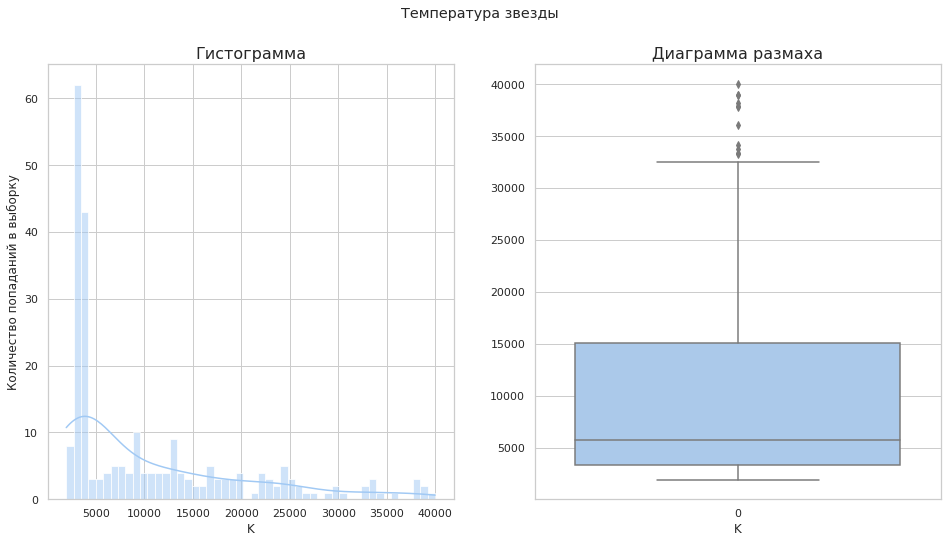

count      240.00
mean    10,497.46
std      9,552.43
min      1,939.00
25%      3,344.25
50%      5,776.00
75%     15,055.50
max     40,000.00
Name: temperature, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод для температуры
print(discr_num(stars['temperature'],
                   'Температура звезды',
                   'K'))

Мы можем наблюдать, что температура у нас распределена группами, и что более холодных звезд у нас меньше, чем более горячих (что похоже на распределение по цветовым классам).

Взглянем на аномально горячие звезды, которые ящиком с усами трактуюся как выбросы.

In [ ]:
# смотрим аномалии по температуре
stars[stars['temperature']>33000]

,temperature,luminosity,radius,magnitude_abs,type,color,color_class
30,39000,"204,000.00",10.60,-4.70,3,blue,O
49,33750,"220,000.00",26.00,-6.10,4,blue,O
99,36108,"198,000.00",10.20,-4.40,3,blue,O
100,33300,"240,000.00",12.00,-6.50,4,blue,O
101,40000,"813,000.00",14.00,-6.23,4,blue,O
109,33421,"352,000.00",67.00,-5.79,4,blue,O
159,37800,"202,900.00",6.86,-4.56,3,blue,O
214,34190,"198,200.00",6.39,-4.57,3,blue,O
231,38234,"272,830.00","1,356.00",-9.29,5,blue,O
235,38940,"374,830.00","1,356.00",-9.93,5,blue,O


Эти звезды относятся к одному (верному) цветовому классу, но имеют разнообразие по другим параметрам.

У части них очень большой относительный радиус (у некоторых - даже одинаковый). Но так как они относятся к классу 5 (Гипергигант) данные выглядят правдоподобными. И хотя открытые источники [5](https://ru.wikipedia.org/wiki/%D0%93%D0%B8%D0%BF%D0%B5%D1%80%D0%B3%D0%B8%D0%B3%D0%B0%D0%BD%D1%82), [6](https://translated.turbopages.org/proxy_u/en-ru.ru.b2d6761f-67dd546d-ac5bfa7d-74722d776562/https/www.space.com/41290-biggest-star.html) и [7](https://trashbox.ru/topics/126028/samye-bolshie-obekty-vo-vselennoj) называют разные размеры, характерные для звезд этого класса, в целом они допускают существование звезд такого размера (например, согласно источнику 6, звезда NML Лебедя в 1639 раз больше Солнца в диаметре, а согласно источнику 7 радиус данного красного гипергиганта и вовсе оценивают от 1 642 до 2 755 радиусов Солнца).

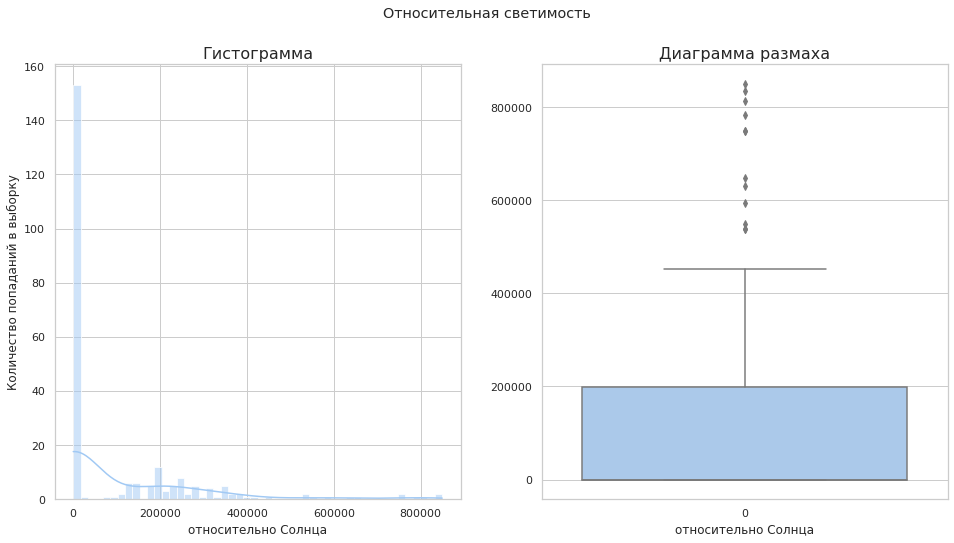

count       240.00
mean    107,188.36
std     179,432.24
min           0.00
25%           0.00
50%           0.07
75%     198,050.00
max     849,420.00
Name: luminosity, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод для относительной светимости
print(discr_num(stars['luminosity'],
                   'Относительная светимость',
                   'относительно Солнца'))

Мы можем наблюдать, что подавляющее большинство звезд не сильно отличаются по светимости от Солнца (также видна еще одна группа звезд приблизительно от 10 тыс до 40 тыс). Но есть и исключения.

Посмотрим на них.

In [ ]:
# смотрим аномалии по относительной светимости
stars[stars['luminosity']>500000]

,temperature,luminosity,radius,magnitude_abs,type,color,color_class
53,3749,"550,000.00","1,648.00",-8.05,5,orange,K
101,40000,"813,000.00",14.00,-6.23,4,blue,O
172,4287,"630,000.00","1,315.00",-9.20,5,orange,K
223,23440,"537,430.00",81.00,-5.97,4,blue,O
226,9892,"593,900.00",80.00,-7.26,4,blue,O
227,10930,"783,930.00",25.00,-6.22,4,blue,O
229,21738,"748,890.00",92.00,-7.35,4,blue,O
232,32489,"648,430.00","1,948.50",-10.84,5,blue,O
233,27739,"849,420.00","1,252.00",-7.59,5,blue white,B
234,21904,"748,490.00","1,130.00",-7.67,5,blue white,B


Это звезды разных типов и температур, среди которых встречаются звезды огромным относительным радиусом. Но все они имеют отрицательную абсолютную звездную величину из относительно близкого диапазона (поэтому можно предположить связь между абсолютную звездной величиной и относительной светимостью).

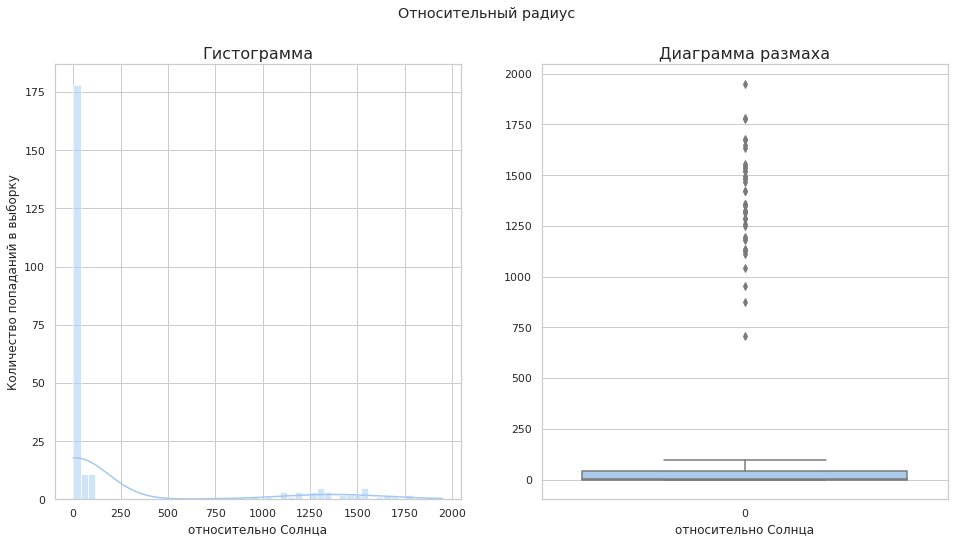

count     240.00
mean      237.16
std       517.16
min         0.01
25%         0.10
50%         0.76
75%        42.75
max     1,948.50
Name: radius, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод для относительного радиуса
print(discr_num(stars['radius'],
                   'Относительный радиус',
                   'относительно Солнца'))

Тут мы также наблюдаем две условыне группы: близкие по параметрам к Солнцу (куда относится большинство объектов выборки), и резко отличающиеся от него.

Посмотрим на аномальные объекты.

In [ ]:
# смотрим аномалии по относительному радиусу
stars[stars['radius']>600]

,temperature,luminosity,radius,magnitude_abs,type,color,color_class
50,3490,"270,000.00","1,520.00",-9.40,5,red,M
51,3750,"283,000.00","1,260.00",-7.63,5,red,M
52,3834,"272,000.00","1,183.00",-9.20,5,red,M
53,3749,"550,000.00","1,648.00",-8.05,5,orange,K
54,3650,"310,000.00","1,324.00",-7.79,5,red,M
55,3450,"263,000.00","1,349.00",-11.75,5,red,M
56,3660,"363,000.00","1,673.00",-11.92,5,red,M
57,3450,"174,000.00","1,284.00",-11.28,5,red,M
58,3752,"209,000.00",955.00,-11.24,5,red,M
59,3535,"195,000.00","1,546.00",-11.36,5,red,M


In [ ]:
# считаем аномалии по относительному радиусу
len(stars[stars['radius']>600])

40

Таких объектов (резко отличающихся по параметрам от Солнца) достоточно много (20% выборки), они как раз и составляюи вторую заметную на гистограмме группу.

И все они имеют общие признаки: отрицательную абсолютную звездную величину из достаточно узкого диапазона, очень большие относительные радиус и светимость, а также единый тип звезды. Так что также можем предположить наличие взаимосвязи между признаками (вплоть до того, что возможно признак с типом звезды придется удалять как слишком высоко коррелирующий не только с относительным радиусом, но и некоторыми другими).

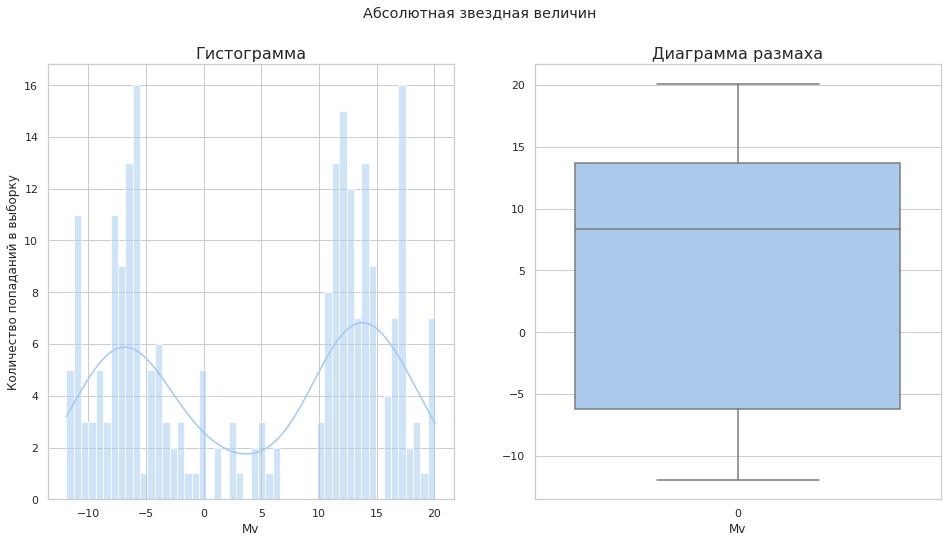

count   240.00
mean      4.38
std      10.53
min     -11.92
25%      -6.23
50%       8.31
75%      13.70
max      20.06
Name: magnitude_abs, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод для абсолютной звездной величины
print(discr_num(stars['magnitude_abs'],
                   'Абсолютная звездная величин',
                   'Mv'))

Здесь стремление звезд разбиться на группы видно уже более явно - мы имеем два хорошозаметных пика на гистограмме распределения. И при этом не наблюдаем ничего, что бы ящик с усами считал аномалиями.

*Примечание:* Самая горячая из известных звёзд — звезда класса Вольфа — Райе в созвездии Стрельца (WR 102). Её эффективная температура — 210 000 К. Самой холодной из когда-либо обнаруженных звёзд считается WISE J085510.83-071442.5. Она относится к классу коричневых карликов. Температура на её поверхности находится в диапазоне между -13 и -48 градусов по Цельсию.

#### Корреляционный анализ

##### Матрица корреляции

Ранее мы могли увидеть, что звезды пытаются разбиться на две группы: близкие к Солнцу по параметрам и разко отличающиеся от него.

А также предположили некоторые взаимосвязи между параметрами. Для их подтверждения или опровержения используем матрицу корреляции.

In [ ]:
# вспоминаем список столбцов
stars.columns

Index(['temperature', 'luminosity', 'radius', 'magnitude_abs', 'type', 'color',
       'color_class'],
      dtype='object')

In [ ]:
# неприрывные значения
interval_cols = ['temperature', 'luminosity', 'radius', 'magnitude_abs']

In [ ]:
# считаем корреляции
#phik_overview = stars.drop('color', axis = 1).phik_matrix(interval_cols=interval_cols)
phik_overview = stars.phik_matrix(interval_cols=interval_cols)

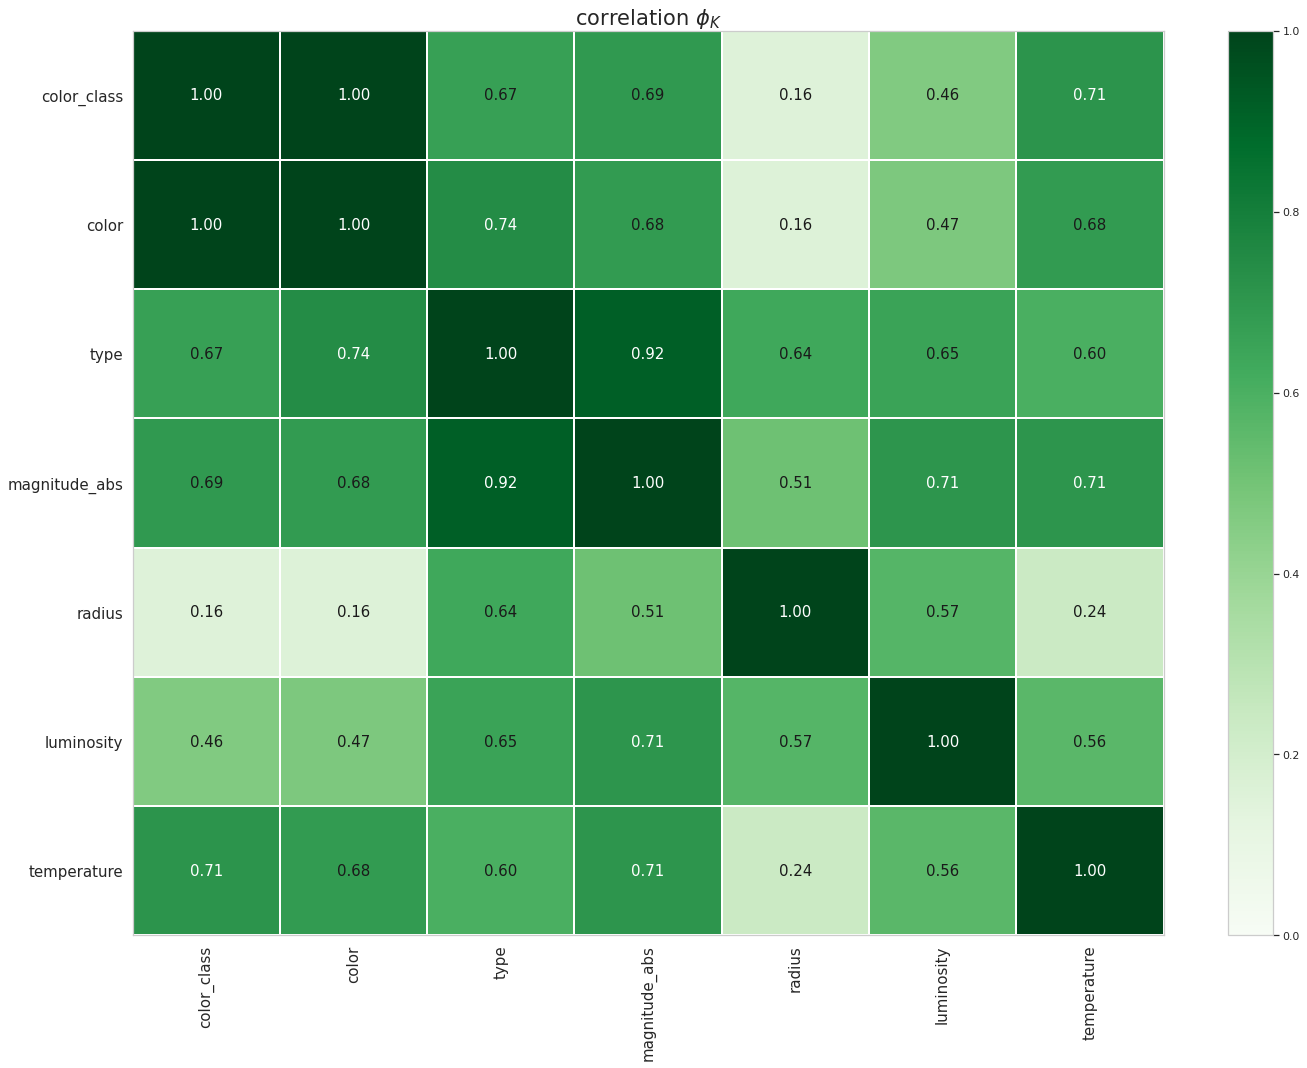

In [ ]:
# матрица корреляции
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Мы можем наблюдать, что меньше всего наш целевой признак (температура) коррелирует с относительным радиусом, а больше всего - с цветовым классом и относительной звездной величиной.

Также высокая степерь корреляции у типа звезды и ее относительной звездной величиной, но мультиколлинеарности эта связь все-таки не достигает.

Также мы можем наблюдать ожидаемую мультиколлинеарность между цветом и цветовым классом(поэтому один из признаков будем исключать из обучения). При этом они во многих случаях ведут себя практически одинаково, однако связь межу типом и цветом заметно выше, чем между типом и классом цвета.

##### Дополнительный графики

Матрицу корреляции мы уже посмотрели. Но можно дополнительно посмотреть связи нашего целевого признака с остальными, благо их немного.

In [ ]:
# вспоминаем список столбцов
stars.columns

Index(['temperature', 'luminosity', 'radius', 'magnitude_abs', 'type', 'color',
       'color_class'],
      dtype='object')

Посмотрим сначала просто на связь двух категориальных признаков.

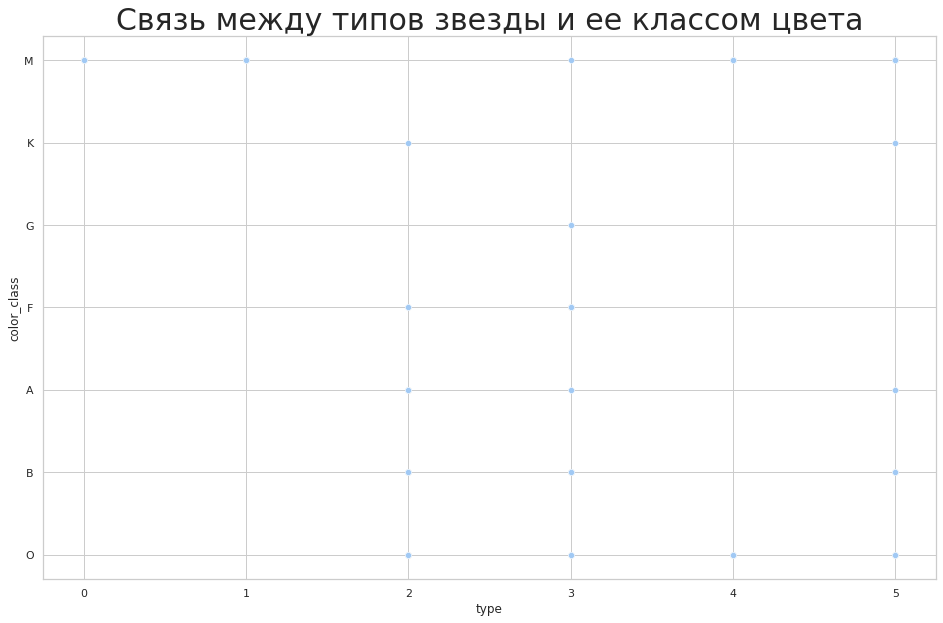

In [ ]:
# связь между категориальными признаками
plt.figure(figsize=(16,10))

sns.scatterplot(data=stars, x='type', y='color_class')
#plt.legend(loc='upper center')
plt.title('Связь между типов звезды и ее классом цвета', fontsize=30)

plt.show()

Первые два типа звезд имеют по одному (одинаковому) классу цвета (у остальных разнообразие выше). А единственные, кто имеют цветовой класс G - звезды типа 3.

Подключим целевой признак для наблюдений.

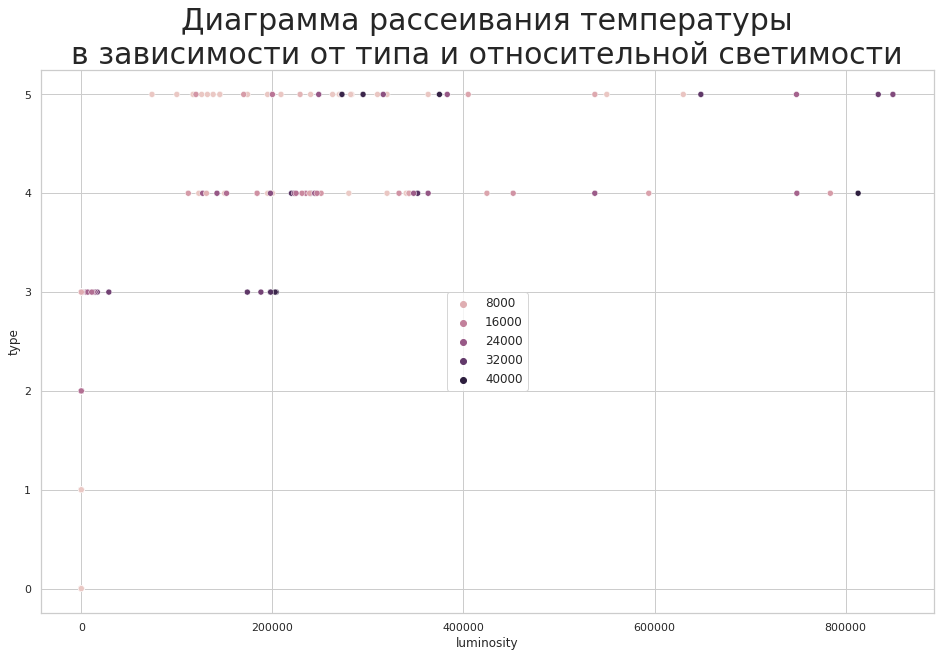

In [ ]:
# диаграмма рассеяния 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=stars, hue='temperature', x='luminosity', y='type')
plt.legend(loc='center')
plt.title('Диаграмма рассеивания температуры\n\
в зависимости от типа и относительной светимости', fontsize=30)

plt.show()

Несмотря на ранее отмеченную среднюю корреляцию между температурой и относительной светимостью какие-то строгие тенденции обнаружить на графике проблематично. Зато можно увидеть связь между относительной светимостью и типом звезды: чем больше номер типа, тем больше в целом ее относительная светимость.

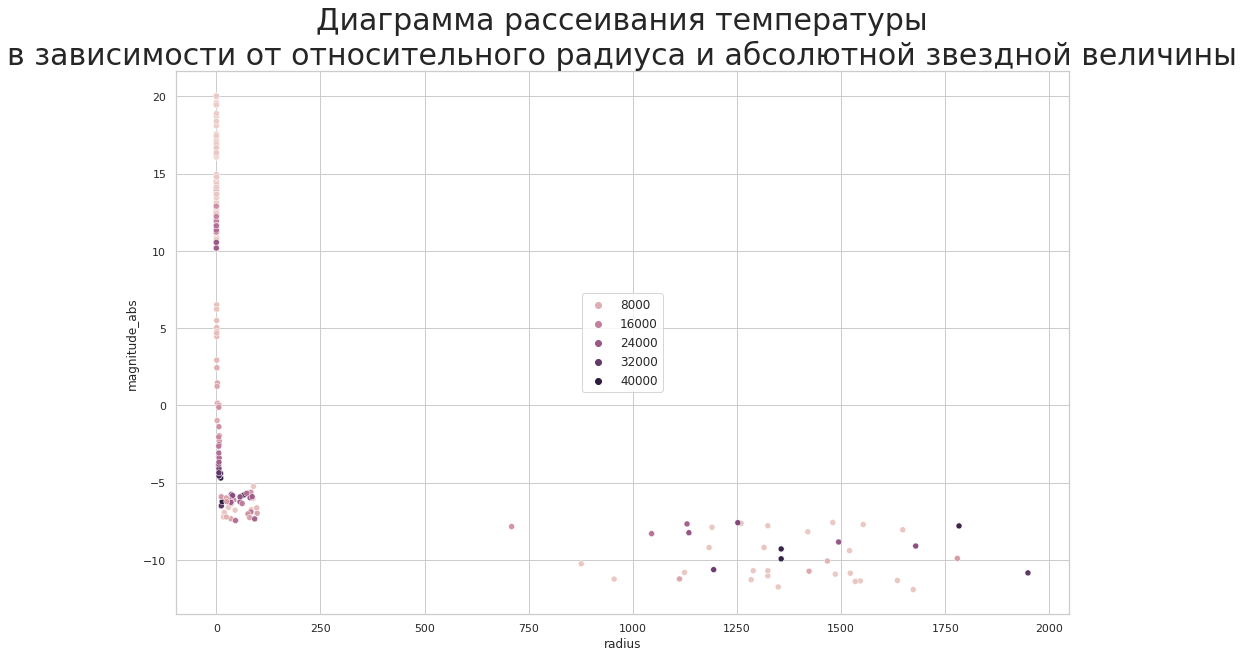

In [ ]:
# диаграмма рассеяния 2
plt.figure(figsize=(16,10))

sns.scatterplot(data=stars, hue='temperature', x='radius', y='magnitude_abs')
plt.legend(loc='center')
plt.title('Диаграмма рассеивания температуры\n\
в зависимости от относительного радиуса и абсолютной звездной величины', fontsize=30)

plt.show()

Тут мы снова наблюдаем две большие группы звезд, причем внутри одной из них ("солнцеподобных") можно выделить еще три подгруппы (итого - целых четыре скопления).

Для групп звезд с большим радиусом и одной из подгрупп "солнцеподобных" (тех, кто имеет больший радиус) какие-то закономерности обнаружить проблематично. Зато по оставшимся двум подгруппам "солнцеподобных" можно сказать, что чем меньшая абсолютная звездная величина - тем больше температура звезды.

Исходя из открытх источников мы можем предположить, что чем более высокая температура дает более синий свет. Но на всякий случай проверим данные на предмет аномалий.

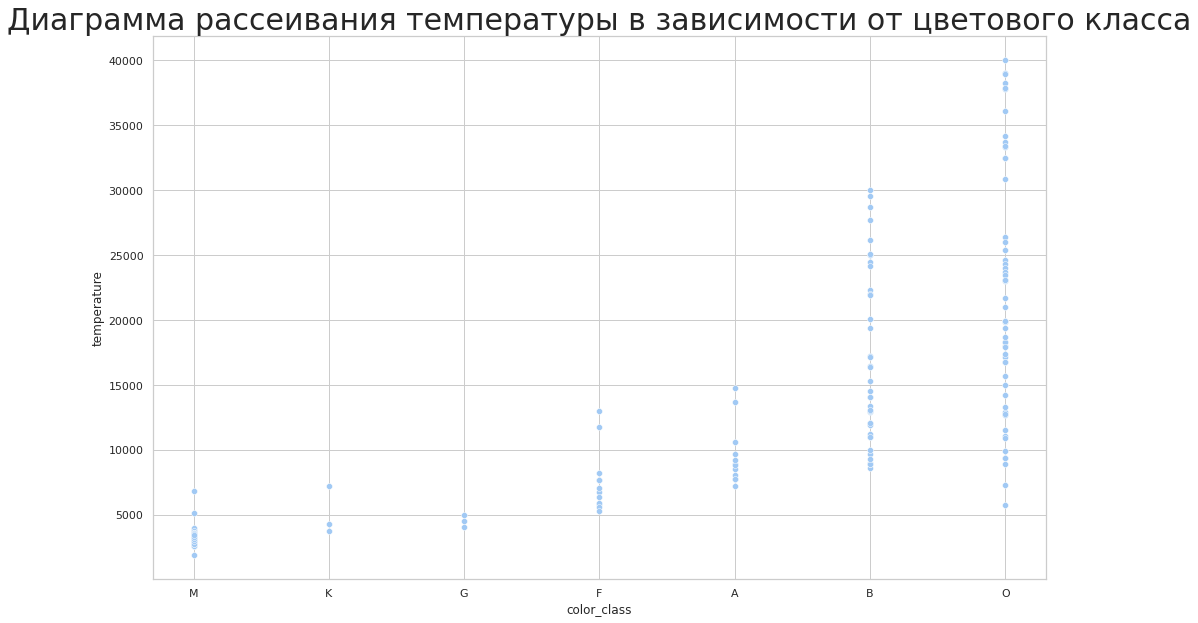

In [ ]:
# диаграмма рассеяния 3
plt.figure(figsize=(16,10))

sns.scatterplot(data=stars, x='color_class', y='temperature')

plt.title('Диаграмма рассеивания температуры в зависимости от цветового класса', fontsize=30)

plt.show()

В целом мы действительно наблюдаем, что для более красных оттенков характерна более низкая температура, а более высокие температуры сколонны давать более синий цвет. Но при этом мы наблюдаем, что самый синий из возможных вариантов могут давать звезды практически любой температуры, что противоречит распостраняющихся на большинство звезд данных открытых источников.

Поэтому мы можем предположить, что либо в данных ошибка, либо имеются звезды, которые нельзя отнести к большинству. Это, например, согласно источнику 1, классы L, T, Y для коричневых карликов или C, S для углеродных звёзд и циркониевых звёзд. Для звёзд Вольфа — Райе используют класс W, для планетарных туманностей — P, для новых звёзд — Q.

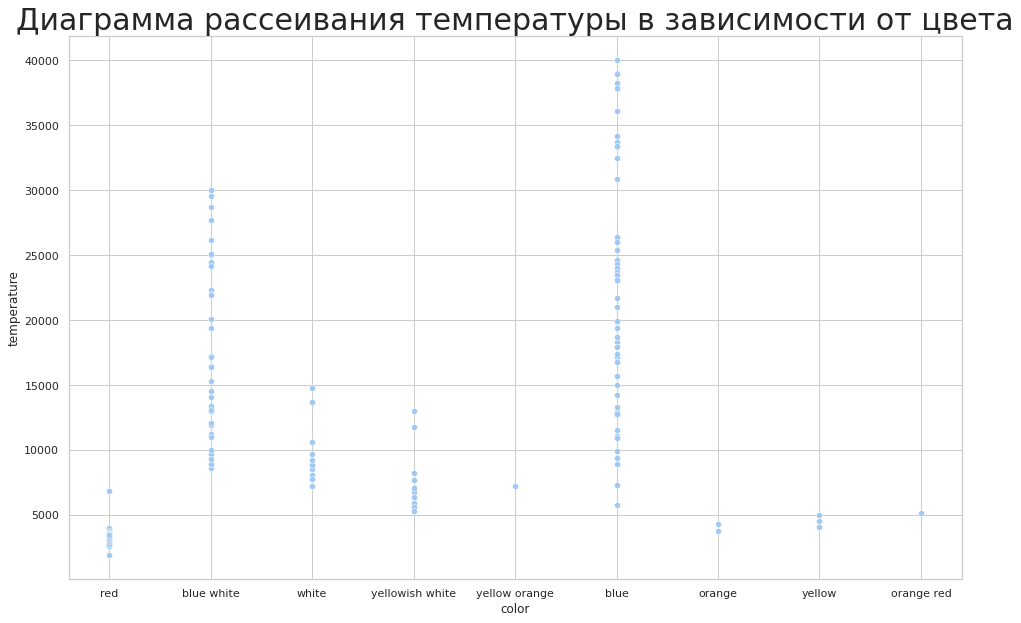

In [ ]:
# диаграмма рассеяния 4
plt.figure(figsize=(16,10))

sns.scatterplot(data=stars, x='color', y='temperature')

plt.title('Диаграмма рассеивания температуры в зависимости от цвета', fontsize=30)

plt.show()

Так как иерархию цветам (в отличие от классов) мы не задавали, то данный график читать сложнее. Но все-равно заметна хаотичность данных, не укладывающася в ранее принятую условность.

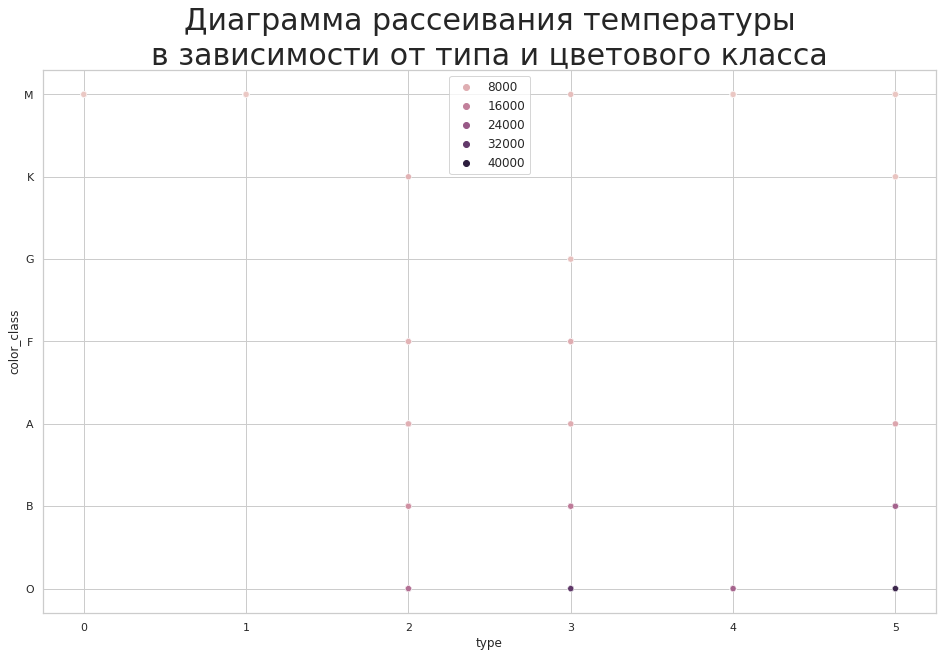

In [ ]:
# диаграмма рассеяния 5
plt.figure(figsize=(16,10))

sns.scatterplot(data=stars, hue='temperature', x='type', y='color_class')
plt.legend(loc='upper center')
plt.title('Диаграмма рассеивания температуры\n\
в зависимости от типа и цветового класса', fontsize=30)

plt.show()

Звезды с большим номером типа в целом склонны к большей температуре и более синему спектру.

Так как наша классификация по цветам оказалась несовершенна (и похоже неверна), исправим ее.

Для этого попробуем использовать исходный `'color'` и "базовые цвета", в них содержащиеся, чтобы закодировать цвета иным образом. Это позволит сделать преобразование цветов в будущем более универсальным, и, хоть и увеличивает количество признаков, для каждого из них становится лишь два варинта, что может немного компенсировать малое количество каких-либо групп.

**Выводы**

- Все представленные изначально признаки имеют связь с целевым и между собой.
- По типам звезды представленны равномерно.
- Некоторые классы цветов имеют очень мало представителей, поэтому могут вносить искажения в обучение.
- Основная часть звезд стремиться к параметрам, характерным для Гарвардской классификации звезд по спектру, но есть и аномалии, которые могут приводить к искажению результатов. При этом диаграмма рассеяния температуры от цветового класса не выявила достаточно сильной зависимости между ними, как должно было бы быть, соответствуй наши звезды данной системе. Поэтому наша цветовая классификация условна и будет использоваться лишь для удобства.
- Более холодных звезд в выборке представленно больше.
- Обнаружили склонность звезд к группировке по отношению к различным признакам (по одному или двум связанным сразу).
- По светимости относительно Солнца звезды стремяться разделиться на несколько условных группы, и группа "солнцеподобных" составляет большинство.
- По радиусам относительно Солнца звезды также стремяться разделиться на две группы, и это разделение более заметно, чем у светимости. Группа "солнцеподобных" также составляет большинство.
- Разбиение на две группы по абсолютной звездной величине уже более заметно, визуально группы сопоставимы по размерам.

**Выводы**

- Провели подготовку данных, которую возможно в будущем будет необходимо доработать.
- Изучили распределение признаков и связи между ними.
- Обнаружили склонность звезд к группировкам по отношению к одному или нескольким связанным между собой признакам.
- Все представленные изначально признаки имеют связь с целевым и между собой.

# Блок 1

В данном блоке поместились первые модели. Данные для них получались подряд, из путем модернизации ранее загруженного дастасета. а также некоторые выборки могли использоваться в нескольтких моделях.

Также часть классов, функций и так далее, прописанных в одной модели, могли использоваться далее (не всегда дублируясь в самой модели).

В итоговый ноутбук попала лучшая модель из своей ветки.

## Вариант 3

### Подготовка данных к построению модели

Вспомним, как у нас выглядит датасет после предварительных преобразований.

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(stars,'stars', 10)


 === Первые 10 строк в stars: ===



,temperature,luminosity,radius,magnitude_abs,type,color,color_class
0,3068,0.00,0.17,16.12,0,red,M
1,3042,0.00,0.15,16.60,0,red,M
2,2600,0.00,0.10,18.70,0,red,M
3,2800,0.00,0.16,16.65,0,red,M
4,1939,0.00,0.10,20.06,0,red,M
5,2840,0.00,0.11,16.98,0,red,M
6,2637,0.00,0.13,17.22,0,red,M
7,2600,0.00,0.10,17.40,0,red,M
8,2650,0.00,0.11,17.45,0,red,M
9,2700,0.00,0.13,16.05,0,red,M



 === Общая информация о данных в stars: ===

<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   temperature    240 non-null    int64   
 1   luminosity     240 non-null    float64 
 2   radius         240 non-null    float64 
 3   magnitude_abs  240 non-null    float64 
 4   type           240 non-null    int64   
 5   color          240 non-null    object  
 6   color_class    240 non-null    category
dtypes: category(1), float64(3), int64(2), object(1)
memory usage: 21.8+ KB


None


 === Размер датасета stars:===
    (240, 7)



In [ ]:
target = 'temperature' # задаем целевой признак

In [ ]:
# проверяем список числовых признаков
num_col_names

['temperature', 'luminosity', 'radius', 'magnitude_abs']

Так как `'temperature'` - целевой признак, мы должны наконец исключить его из списка.

In [ ]:
# изменяем список числовых
num_col_names.remove(target) # удаляем целевой
num_col_names # проверяем

['luminosity', 'radius', 'magnitude_abs']

Несмотря на то, что наша классификация звезд по цветам оказалась не совсем корректной в научном плане, сохраним ее для обучения модели, чтобы не переименовывать значения дополнительно.

In [ ]:
# проверяем список категориальных признаков
cat_col_names

['type', 'color_class']

In [ ]:
# список признаков, которые мы берем в работу
feat_p = cat_col_names + num_col_names
feat_p

['type', 'color_class', 'luminosity', 'radius', 'magnitude_abs']

Разобьем данные на выборки.

In [ ]:
# функция подготовки данных перед подбором моделей и их параметров
# со стратификацией по одному из признаков
def data_preprocessing(data, target_name):

    # Перемешивание объектов
    # для их лучшего распределения в выборках
    data = shuffle(data, random_state=RANDOM_STATE)

    # Разделение датафреймов на целевую и нецелевую выборку
    features = data.drop([target_name], axis=1)
    target = data[target_name]

    # Разделение целевой и нецелевой выборки
    # на обучающие и тестовые выборки
    X_train, X_valid, y_train, y_valid = train_test_split(
        features,
        target,
        shuffle = True, # перемешивание, больше нужно для задач классификации
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=data['color_class'] # стратификация по указанному признаку
    )

    return X_train, X_valid, y_train, y_valid

In [ ]:
# Разделение обучающего датафрейма на целевую и тестовую выборку
X_train_p, X_valid_p, y_train_p, y_valid_p = data_preprocessing(stars[feat_p+[target]], target)

In [ ]:
# проверка разбиения
print(color.BLUE + color.BOLD + f"Размер X_train_p: "\
      + color.END + f"{X_train_p.shape}")
print(color.BLUE + color.BOLD + f"Размер X_valid_p: "\
      + color.END + f"{X_valid_p.shape}")
print(color.BLUE + color.BOLD + f"Размер y_train_p: "\
      + color.END + f"{y_train_p.shape}")
print(color.BLUE + color.BOLD + f"Размер y_valid_p: "\
      + color.END + f"{y_valid_p.shape}")

Размер X_train_p: (168, 5)
Размер X_valid_p: (72, 5)
Размер y_train_p: (168,)
Размер y_valid_p: (72,)


In [ ]:
# просмотр первых строк
X_train_p.head()

,type,color_class,luminosity,radius,magnitude_abs
237,5,A,"537,493.00","1,423.00",-10.73
103,4,O,"235,000.00",83.00,-6.89
129,0,M,0.00,0.09,18.09
5,0,M,0.00,0.11,16.98
19,1,M,0.04,0.35,11.18


In [ ]:
# просмотр первых строк
y_train_p.head()

237     8829
103    17120
129     2731
5       2840
19      3441
Name: temperature, dtype: int64

Теперь можно преобразовывать.

Попробуем сделать подготовку через пайплайн. Также в этот раз будем использовать OHE для кодировки категориальных признаков. И обойдемся без скалирования целевого признака.

In [ ]:
# собираем преобразователь
col_transformer_p = ColumnTransformer(
                        transformers=[
                            ('scaler', StandardScaler(), num_col_names), # числовые
                            ('ohe', OneHotEncoder(drop='first', # избегаем дамми-ловушки
                                                  handle_unknown='ignore', # игнорируем неизвестные значения
                                                  sparse_output=False), # "сохраняем" имена
                             cat_col_names)], # категориальные
                                remainder="passthrough" # не изменяем неуказанные столбцы
                                  )

In [ ]:
# тренируем
col_transformer_p.fit(X_train_p)

ColumnTransformer(remainder='passthrough',
                  transformers=[('scaler', StandardScaler(),
                                 ['luminosity', 'radius', 'magnitude_abs']),
                                ('ohe',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['type', 'color_class'])])

In [ ]:
# преобразуем тренировочные данные
X_train_p_sc = col_transformer_p.transform(X_train_p)
pd.DataFrame(X_train_p_sc).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,2.54,2.22,-1.42,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.77,-0.31,-1.05,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2,-0.61,-0.47,1.32,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
3,-0.61,-0.47,1.21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
4,-0.61,-0.47,0.66,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00


In [ ]:
# преобразуем валидационные
X_valid_p_sc = col_transformer_p.transform(X_valid_p)
pd.DataFrame(X_valid_p_sc).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.61,-0.47,1.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0.70,-0.36,-0.96,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2,-0.61,-0.47,0.98,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
3,0.99,2.09,-1.28,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
4,-0.61,-0.47,0.60,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00


Данные трансформированы. Можно переходить к самой модели.

### Построение базовой нейронной сети

Для начала снова необходимо получить тензоры.

In [ ]:
# преобразование выборок в тензоры
# менее явный, может привести к неожидонностям с типами данных
X_train_tensor = torch.Tensor(X_train_p_sc)
X_valid_tensor  = torch.Tensor(X_valid_p_sc)
y_train_tensor = torch.Tensor(y_train_p.values)
y_valid_tensor  = torch.Tensor(y_valid_p.values)

In [ ]:
# проверка размерности тензоров
for x in ['X_train_tensor', 'X_valid_tensor', 'y_train_tensor', 'y_valid_tensor']:
    print(color.BLUE + color.BOLD + f'Размерность {x}: '+ color.END + f'{globals()[x].shape}')

Размерность X_train_tensor: torch.Size([168, 14])
Размерность X_valid_tensor: torch.Size([72, 14])
Размерность y_train_tensor: torch.Size([168])
Размерность y_valid_tensor: torch.Size([72])


Зададим архитектуру сети и ее параметры.

In [ ]:
# cоздадим ПНС
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons):
            super(Net, self).__init__()

            self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
            self.act1 = nn.Tanh()
            self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
            self.act2 = nn.LeakyReLU()
            self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)

        return x

In [ ]:
# количества нейронов
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

In [ ]:
# остальные настройки сети
net = Net(n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons) # инициализация
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3) # оптимизатор
loss = nn.MSELoss() # функция потерь

Доработаем данные для удобства оперирования ими.

In [ ]:
# "упакуем" и настроим данные для обучения
# from torch.utils.data import Dataset, DataLoader # унесено в начало, тут помечено, к чему относится

# Создаем генератор для DataLoader
data_loader_generator = torch.Generator().manual_seed(SEED)

# Создание Dataset и DataLoader
# "соединяем" данные для обучения
dataset_train = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
# "соединяем" данные для валидации
dataset_valid = torch.utils.data.TensorDataset(X_valid_tensor, y_valid_tensor)

# "загружаем" данные для обучения и задаем параметры
train_dataloader = DataLoader(dataset_train, # данные
                              batch_size=40, # размер батча
                              shuffle=True, # перемешивание данных
                              generator=data_loader_generator, # фиксация перемешивания
                              num_workers=0) # количество потоков
# повторяем для валидационных, перемешивание для валидационных данных обычно не нужно
valid_dataloader = DataLoader(dataset_valid, batch_size=40, shuffle=False, num_workers=0)

Чтобы не тратить ресурсы, необходимо остановить обучение при отсутствии улучшений. Для этого нужно прописать класс.

In [ ]:
class CustomEarlyStopping():
    """
    Ранняя остановка, чтобы остановить тренировку, когда потеря не улучшается после определенной эпохи.
    """
    def __init__(self, patience=5, min_delta=0):
        """
        :param patience: сколько эпох ждать, прежде чем остановиться, когда потеря не улучшается
        :param min_delta: минимальная разница между loss/метриками, если улучшений нет, то остановим обучение
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss == None:
            self.best_loss = val_loss
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            # reset counter if validation loss improves
            self.counter = 0
        elif self.best_loss - val_loss < self.min_delta:
            self.counter += 1
            print(f"INFO: Early stopping counter {self.counter} of {self.patience}")
            if self.counter >= self.patience:
                print('INFO: Early stopping')
                self.early_stop = True

In [ ]:
# Обучим нейросеть
early_stopping = CustomEarlyStopping(patience=5, min_delta=20)

num_epochs = 100001 # количество эпох исходное
best_rmse = float('inf')  # Инициализация лучшего RMSE
best_predicted_temp = None  # Сохраним лучшие предсказания

for epoch in range(num_epochs):
    net.train()  # Режим обучения
    for batch in train_dataloader:
        data_train, temperature_train = batch # просто выгружаем данные
        optimizer.zero_grad()

        preds = net.forward(data_train).flatten() # Предсказания

        loss_value = torch.sqrt(loss(preds, temperature_train)) # RMSE-loss
        loss_value.backward()  # Обратное распространение ошибки
        optimizer.step() # Обновление весов

    if epoch % 200 == 0:
        predicted_temp = []
        with torch.no_grad(): # Отключаем вычисление градиентов
            net.eval() # Режим оценки
            for batch in valid_dataloader:
                data_valid, temperature_valid = batch # просто выгружаем данные

                valid_preds = net.forward(data_valid).flatten() # Предсказания на валидации
                predicted_temp.append(valid_preds) # Добавляем в список
                RMSE_loss = torch.sqrt(loss(valid_preds, temperature_valid))

        # Объединяем все батчи в один тензор и преобразуем в numpy
        predicted_temp = torch.cat(predicted_temp).detach().numpy()
        # Вычисляем RMSE (используем numpy-версию y_valid)
        RMSE = mean_squared_error(y_valid_tensor.numpy(), predicted_temp, squared=False)

        # Проверяем, нужно ли остановиться
        early_stopping(RMSE)
        if early_stopping.counter == 0: # Если улучшилось
            best_rmse = RMSE
            best_predicted_temp = predicted_temp
        print(f"epoch:{epoch}, RMSE test: {RMSE}")

        # Если сработал ранний стоп
        if early_stopping.early_stop:
            print('Early Stoppning!!!'+ color.END)
            print(f'Best RMSE test {best_rmse}')
            break

epoch:0, RMSE test: 14165.3427734375


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


epoch:200, RMSE test: 13988.7958984375


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


epoch:400, RMSE test: 13580.71875


...

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


INFO: Early stopping counter 3 of 5
epoch:6200, RMSE test: 3855.099853515625


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


INFO: Early stopping counter 4 of 5
epoch:6400, RMSE test: 3835.195556640625
INFO: Early stopping counter 5 of 5
INFO: Early stopping
epoch:6600, RMSE test: 3837.591796875
Early Stoppning!!!
Best RMSE test 3785.418212890625


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Мы уже можем наблюдать неплохие результаты. Построим график для визуализации.

In [ ]:
# задаем параметры
def fact_forecast(valid_preds, y_valid):
    '''Функция для визуализации качества регрессии "Факт-прогноз"'''

    y1 = valid_preds.reshape(-1)  # Прогноз (уже numpy-массив)
    y2 = y_valid.detach().numpy().reshape(-1)  # Факт
    x = np.arange(len(y1))  # Ось X

    fig, ax = plt.subplots(figsize=(18, 8))

    # Смещаем столбцы, чтобы они не перекрывались
    width = 0.4
    ax.bar(x - width/2, y2, width=width, label='Факт', alpha=0.7)
    ax.bar(x + width/2, y1, width=width, label='Прогноз', alpha=0.7)

    ax.set_title('График "Факт-прогноз"', fontsize=20)
    ax.set_xlabel('Номер звезды')
    ax.set_ylabel('Температура звезды')
    ax.legend()
    plt.show()

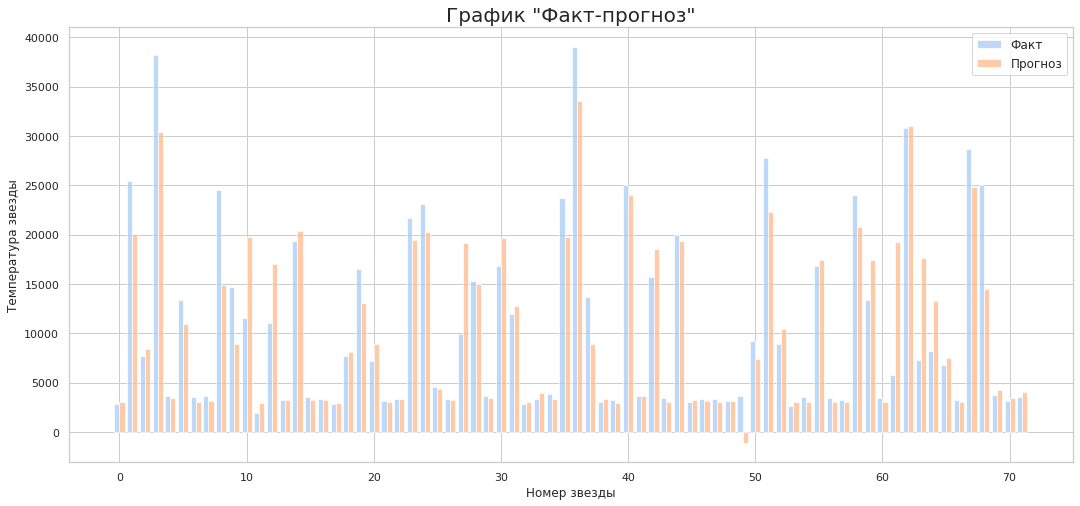

In [ ]:
# строим график
fact_forecast(predicted_temp, y_valid_tensor)

Построенная baseline модель без дополнительных настроек даетотличную метрику, гораздо ниже требуемой.

Мы можем наблюдать, что модель неплохо предсказывает результат для большинства звезд (с температурой менее 5 тысяч К), однако для более горячих модель склонна завышать или занижать результаты.

С учетом небольшого количества даных - это хороший результат, который можно попробовать улучшить.

**Вывод**

Создана базовая модель, превосходящая требуемую метрику. Однака, она склонна занижать или завывшать температуру особо горячик звезд, поэтому попробуем ее улучшить.

### Улучшение нейронной сети

In [ ]:
# Дополнительная фиксация случайности перед обучением
def reset_seed():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

reset_seed() # нужно перед каждым GridResearch/RandomSearch или ручным перебором

In [ ]:
# перенастраиваем сеть
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

net = Net(n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons)
# используем несколько оптимизаторов
optimizer1 = torch.optim.Adam(net.parameters(), lr=1e-3)
optimizer2 = torch.optim.NAdam(net.parameters(), lr=1e-2)
optimizer3 = torch.optim.Adamax(net.parameters(), lr=1e-2)
optimizer4 = torch.optim.Adamax(net.parameters(), lr=1e-3)
optimizer5 = torch.optim.Adam(net.parameters(), lr=1e-2)

optimizers = [optimizer1, optimizer2, optimizer3, optimizer4, optimizer5]

In [ ]:
# Список для хранения результатов
optimizer_results = []

for optimizer in optimizers:
    print(color.BLUE + color.BOLD + f"\n=== Тестируем оптимизатор: {optimizer.__class__.__name__},\
    lr={optimizer.param_groups[0]['lr']} ===" + color.END)

    # Инициализация модели (с фиксированным seed) для каждого оптимизатора заново
    torch.manual_seed(SEED)  # Фиксируем инициализацию весов
    net = Net(n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons)
    optimizer = optimizer.__class__(net.parameters(), lr=optimizer.param_groups[0]['lr'])

    early_stopping = CustomEarlyStopping(patience=5, min_delta=20)
    best_rmse = float('inf')
    best_epoch = 0

    for epoch in range(100001):
        # Обучение
        net.train()
        for batch in train_dataloader:
            X_batch, y_batch = batch
            optimizer.zero_grad()
            outputs = net(X_batch).flatten()
            loss_value = torch.sqrt(loss(outputs, y_batch))
            loss_value.backward()
            optimizer.step()

        # Валидация каждые 200 эпох
        if epoch % 200 == 0:
            net.eval()
            with torch.no_grad():
                val_preds = []
                for batch in valid_dataloader:
                    X_val, y_val = batch
                    preds = net(X_val).flatten()
                    val_preds.append(preds)

                val_preds = torch.cat(val_preds)
                current_rmse = torch.sqrt(loss(val_preds, y_valid_tensor)).item()

                # Обновляем лучший результат
                if current_rmse < best_rmse:
                    best_rmse = current_rmse
                    best_epoch = epoch
                    best_preds = val_preds.numpy()

                # Проверяем раннюю остановку
                early_stopping(current_rmse)
                print(f"Эпоха {epoch}: RMSE = {current_rmse:.4f} | Лучший RMSE = {best_rmse:.4f}")

                if early_stopping.early_stop:
                    print(f"Ранняя остановка! Лучший RMSE = {best_rmse:.4f} на эпохе {best_epoch}")
                    break

    # Сохраняем результаты для этого оптимизатора
    optimizer_results.append({
        'name': f"{optimizer.__class__.__name__} (lr={optimizer.param_groups[0]['lr']})",
        'best_rmse': best_rmse,
        'best_preds': best_preds
    })

# Выводим сравнение всех оптимизаторов
print(color.BLUE + color.BOLD + f"\n=== Результаты сравнения оптимизаторов ==="+ color.END)
for result in sorted(optimizer_results, key=lambda x: x['best_rmse']):
    print(f"{result['name']}: Лучший RMSE = {result['best_rmse']:.4f}")


=== Тестируем оптимизатор: Adam,    lr=0.001 ===
Эпоха 0: RMSE = 14165.3428 | Лучший RMSE = 14165.3428
Эпоха 200: RMSE = 13988.8105 | Лучший RMSE = 13988.8105
Эпоха 400: RMSE = 13580.6543 | Лучший RMSE = 13580.6543
Эпоха 600: RMSE = 13018.9697 | Лучший RMSE = 13018.9697
Эпоха 800: RMSE = 12360.5996 | Лучший RMSE = 12360.5996
Эпоха 1000: RMSE = 11657.3818 | Лучший RMSE = 11657.3818
Эпоха 1200: RMSE = 10894.0166 | Лучший RMSE = 10894.0166
Эпоха 1400: RMSE = 10105.6475 | Лучший RMSE = 10105.6475
Эпоха 1600: RMSE = 9284.5801 | Лучший RMSE = 9284.5801
Эпоха 1800: RMSE = 8309.5869 | Лучший RMSE = 8309.5869
Эпоха 2000: RMSE = 7439.8774 | Лучший RMSE = 7439.8774
Эпоха 2200: RMSE = 6709.9453 | Лучший RMSE = 6709.9453
Эпоха 2400: RMSE = 6169.9263 | Лучший RMSE = 6169.9263
Эпоха 2600: RMSE = 5739.2505 | Лучший RMSE = 5739.2505
Эпоха 2800: RMSE = 5447.8638 | Лучший RMSE = 5447.8638
Эпоха 3000: RMSE = 5339.0825 | Лучший RMSE = 5339.0825
Эпоха 3200: RMSE = 5280.1812 | Лучший RMSE = 5280.1812
Эпоха 

Один из тестируемых оптимизаторов приблизился к нужному уровню.

Пересоздадим модель с ним в качестве оптимизатора, также добавим Dropout в архитектуру.

*Примечание:* Несмотря на мои попытки победить рандом фиксацией случайной величины, побеждают разные оптмизаторы, чаще всего Adamax (lr=0.001) или Adamax (lr=0.01), иногда это не срабатыват с высокой точностью, так как между ними очень маленькая разница.

In [ ]:
# пересоздаем НПС
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons, dropout_rate=0.5):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.Tanh()
        self.dp1 = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.LeakyReLU()
        self.dp2 = nn.Dropout(p=dropout_rate)
        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)

    def forward(self, x):
        x = self.dp1(self.act1(self.fc1(x)))
        x = self.dp2(self.act2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [ ]:
# задаем вывод результата каждые 100 эпох и в последнюю эпоху
# callback только с тренировочным RMSE
class PrintTrainRMSE100(Callback):
    def on_epoch_end(self, net_p, **kwargs):
        epoch = net_p.history[-1]['epoch']
        if epoch % 100 == 0 or epoch == net_p.max_epochs:
            y_pred = net_p.predict(X_train_tensor)
            train_rmse = rmse(y_train_tensor.numpy(), y_pred)
            print(f"Epoch {epoch} | Train RMSE: {train_rmse:.4f}")

In [ ]:
# from sklearn.base import BaseEstimator - потом уехало в начало
# ранняя остановка для gs
class CustomEarlyStoppingGS(BaseEstimator, Callback):
    """
    Ранняя остановка, совместимая с GridSearchCV.
    Наследуемся от BaseEstimator для совместимости с sklearn.
    :param patience: сколько эпох ждать, прежде чем остановиться, когда потеря не улучшается
    :param min_delta: минимальная разница между loss/метриками, если улучшений нет, то остановим обучение
    """
    def __init__(self, patience=10, min_delta=20):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None

    def on_epoch_end(self, net, **kwargs):
        if 'valid_loss' not in net.history[-1]:
            return

        current_loss = net.history[-1]['valid_loss'] # Следим за валидационным loss
        if self.best_loss is None:
            self.best_loss = current_loss
        elif self.best_loss - current_loss > self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print(f"Ранняя остановка: нет улучшений {self.patience} эпох подряд")
                raise KeyboardInterrupt("Early stopping") # остановливаем обучение

In [ ]:
# Инициализация модели с фиксированным оптимизатором Adamax
net_p = NeuralNetRegressor(
    module=Net,
    module__n_in_neurons=n_in_neurons,
    module__n_hidden_neurons_1=n_hidden_neurons_1,
    module__n_hidden_neurons_2=n_hidden_neurons_2,
    module__n_out_neurons=n_out_neurons,
    iterator_train__shuffle=True, # перемешивание
    optimizer=torch.optim.Adamax,  # Класс оптимизатора
    optimizer__lr=1e-3,     # Фиксированный learning rate
    criterion=nn.MSELoss,
    max_epochs=10000,
    verbose=0,
    train_split=None,  # если не используете валидационный сплит (тут мы заранее данные разделили)
    callbacks=[
        ('early_stopping', CustomEarlyStoppingGS(patience=10, min_delta=0.001)), # ранняя остановка
        ('print_metrics', PrintTrainRMSE100()), # вывод каждые 100 эпох
#        ('tqdm', TqdmCallback()),  # Добавляем tqdm прогресс-бар
    ]
)

In [ ]:
# параметры для GridSearch
params_p = {
    'batch_size': [16, 32, 64], # размер батча
    'module__dropout_rate': [0.2, 0.3], # параметры Dropout
    'optimizer__weight_decay': [0, 1e-4] # L2 регуляризация
}

In [ ]:
# Создаем объект кросс-валидации с фиксированным random_state
cv = KFold(n_splits=3, shuffle=True, random_state=SEED)

In [ ]:
# настройка GridSearch
gs_p = GridSearchCV(
    net_p, # модель
    params_p, # параметры
    refit=True, # переобучить лучшую модель на всех данных
    cv=cv, # фолды, заданы ранее
    scoring=rmse_scorer, # метрика
    verbose=2,  # вывод отладочной информации
   # n_jobs=-1 # использовать все ядра процессора
    n_jobs= 1 # для воспроизводимости лучше одно (параллельные вычисления могут вносить детерминизм)
)

In [ ]:
reset_seed() # нужно перед каждым GridResearch/RandomSearch или ручным перебором, для воспроизводимости

In [ ]:
# обучение
# .reshape(-1, 1) - чтобы избежать ошибки, если y_train окажется одномерным тензором, для двумерного ничего не изменится
gs_p.fit(X_train_tensor, y_train_tensor.reshape(-1, 1))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Epoch 100 | Train RMSE: 14173.8477
Epoch 200 | Train RMSE: 14135.8467
Epoch 300 | Train RMSE: 14075.2158
Epoch 400 | Train RMSE: 13993.9277
Epoch 500 | Train RMSE: 13895.0127
Epoch 600 | Train RMSE: 13777.8594
Epoch 700 | Train RMSE: 13643.1660
Epoch 800 | Train RMSE: 13493.7676
Epoch 900 | Train RMSE: 13320.4551
Epoch 1000 | Train RMSE: 13140.3682
Epoch 1100 | Train RMSE: 12941.8184
Epoch 1200 | Train RMSE: 12735.3936
Epoch 1300 | Train RMSE: 12519.9863
Epoch 1400 | Train RMSE: 12300.7461
Epoch 1500 | Train RMSE: 12087.4336
Epoch 1600 | Train RMSE: 11864.4824
Epoch 1700 | Train RMSE: 11654.3174
Epoch 1800 | Train RMSE: 11431.4863
Epoch 1900 | Train RMSE: 11225.5146
Epoch 2000 | Train RMSE: 11033.9316
Epoch 2100 | Train RMSE: 10855.6064
Epoch 2200 | Train RMSE: 10673.8154
Epoch 2300 | Train RMSE: 10449.3047
Epoch 2400 | Train RMSE: 10197.6016
Epoch 2500 | Train RMSE: 10001.7119
Epoch 2600 | Train RMSE: 9799.4775
Epoch 2700 | 

GridSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
             estimator=NeuralNetRegressor(_params_to_validate={'module__n_in_neurons', 'iterator_train__shuffle', 'module__n_hidden_neurons_2', 'optimizer__lr', 'module__n_hidden_neurons_1', 'module__n_out_neurons'}, batch_size=128, callbacks=[('early_stopping', CustomEarlyStoppingGS(min_delta=0.001)), ('pri...max.Adamax'>, optimizer__lr=0.001, predict_nonlinearity='auto', torch_load_kwargs=None, train_split=None, use_caching='auto', verbose=0, warm_start=False),
             n_jobs=1,
             param_grid={'batch_size': [16, 32, 64],
                         'module__dropout_rate': [0.2, 0.3],
                         'optimizer__weight_decay': [0, 0.0001]},
             scoring=make_scorer(rmse, greater_is_better=False, response_method='predict'),
             verbose=2)

In [ ]:
# вывод результатов
print(color.BLUE + color.BOLD + f"\nЛучшие параметры:"+ color.END)
for param, value in gs_p.best_params_.items():
    print(f"{param:>20}: {value}")

print(color.BLUE + color.BOLD + f"\nЛучший RMSE: "+ color.END + f"{-gs_p.best_score_:.4f}")


Лучшие параметры:
          batch_size: 16
module__dropout_rate: 0.2
optimizer__weight_decay: 0.0001

Лучший RMSE: 6806.9097


Модель стала не стала лучше.

In [ ]:
# сохранение лучшей модели из GridSearch
best_model_p = gs_p.best_estimator_

In [ ]:
# получаем предсказания (уже в numpy-формате)
y_pred_p = best_model_p.predict(X_valid_tensor.numpy())  # X_valid должен быть тензором

In [ ]:
# смотрим предсказание
pd.DataFrame(y_pred_p).head()

,0
0,"2,621.25"
1,"20,673.96"
2,"8,622.44"
3,"20,673.61"
4,"3,283.29"


In [ ]:
# создаем DataFrame для сравнения
results_p = pd.DataFrame({
    'Факт': y_valid_tensor.flatten(),
    'Прогноз': y_pred_p.flatten()
}, index=range(len(y_valid_tensor)))

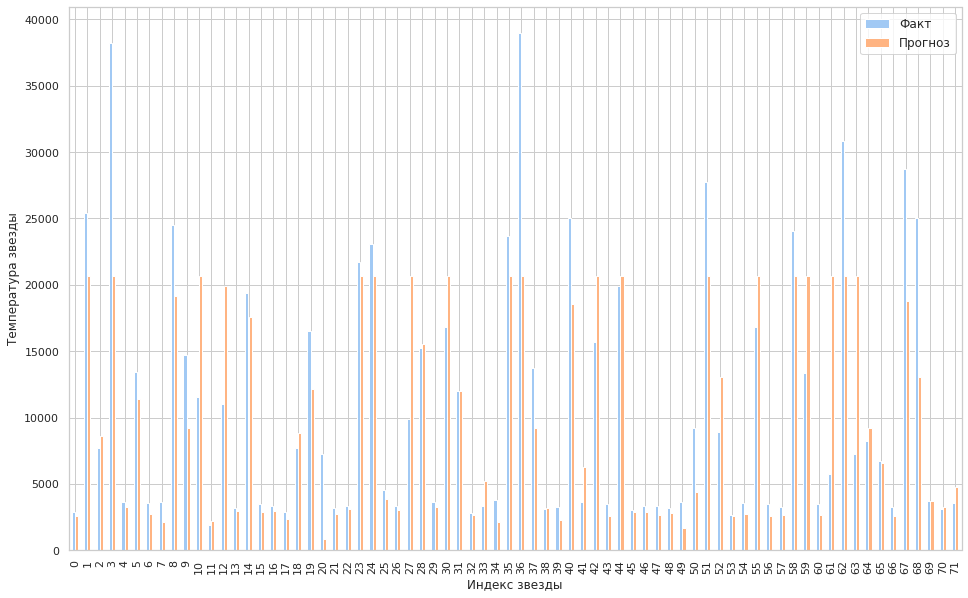

In [ ]:
# график
results_p.plot(kind='bar',figsize=(16,10))
plt.xlabel('Индекс звезды')
plt.ylabel('Температура звезды')
plt.show()

Модель стала хуже: теперь она в принципе склонна занижать результат для всех звезд, что особенно заметно для особо горячих звезд (для которых она склонна усреднять результат в этой "группе", что хорошо видно на самой горячей из имеющейся).

**Вывод**

Попытки улучшить модель относительно baseline не увенчались успехом: изменение размера батча или вероятности Dropout лушь ухудшают метрику, а сама модель начинает занижать результаты для всех звезд (особенно - для самых горячих).

# Блок 2

Данный блок посвящен попыткам улучшить ситуацию, вернувшись к истокам. И собран так, чтобы можно было запускать его отдельно, минуя Блок 1.

## Загрузка данных

С учетом опыта, полученного в первом блоке, попробуем немного поэкспериментировать дополнительно. Чтобы не подтиянуть случайно выборки из первого блока, а также для обработки датасета новым образом, загрузим датасет заново, но также уже с исправленными именами и удаленным неинформативным столбцом.

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка датасета
try:
    stars_new = pd.read_csv('/datasets/6_class.csv', index_col=0).rename(columns=new_column_names)
except:
    stars_new = pd.read_csv('https://адрес_удален/datasets/6_class.csv', index_col=0).rename(columns=new_column_names)

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(stars_new,'stars_new', 10)


 === Первые 10 строк в stars_new: ===



,temperature,luminosity,radius,magnitude_abs,type,color
0,3068,0.00,0.17,16.12,0,Red
1,3042,0.00,0.15,16.60,0,Red
2,2600,0.00,0.10,18.70,0,Red
3,2800,0.00,0.16,16.65,0,Red
4,1939,0.00,0.10,20.06,0,Red
5,2840,0.00,0.11,16.98,0,Red
6,2637,0.00,0.13,17.22,0,Red
7,2600,0.00,0.10,17.40,0,Red
8,2650,0.00,0.11,17.45,0,Red
9,2700,0.00,0.13,16.05,0,Red



 === Общая информация о данных в stars_new: ===

<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    240 non-null    int64  
 1   luminosity     240 non-null    float64
 2   radius         240 non-null    float64
 3   magnitude_abs  240 non-null    float64
 4   type           240 non-null    int64  
 5   color          240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB


None


 === Размер датасета stars_new:===
    (240, 6)



## Предподготовка данных

Заново обработаем названия цветов.

In [ ]:
# вспоминаем варианты цветов
stars_new['color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

In [ ]:
# считаем
print(color.BLUE + color.BOLD +f"Количество уникальных вариантов: "+ color.END + f"{len(stars_new['color'].unique())}")

Количество уникальных вариантов: 19


In [ ]:
# приводим к нижнему регистру и удаляем лишние пробелы
stars_new['color'] = stars_new['color'].str.lower().str.strip()

In [ ]:
# проверка
stars_new['color'].unique()

array(['red', 'blue white', 'white', 'yellowish white',
       'pale yellow orange', 'blue', 'blue-white', 'whitish',
       'yellow-white', 'orange', 'white-yellow', 'yellowish',
       'orange-red'], dtype=object)

In [ ]:
# считаем
print(color.BLUE + color.BOLD +f"Количество уникальных вариантов: "+ color.END + f"{len(stars_new['color'].unique())}")

Количество уникальных вариантов: 13


Как мы помним, можно выделить группы звезд по их спектру.

In [ ]:
# считаем представителей каждого варианта цвета
stars_new['color'].value_counts()

red                   112
blue                   56
blue-white             27
blue white             14
white                  10
yellow-white            8
yellowish               3
yellowish white         3
orange                  2
whitish                 2
orange-red              1
white-yellow            1
pale yellow orange      1
Name: color, dtype: int64

Какие-то из вариантов - явные дубликаты. А каких-то звезд просто очень мало, чтобы их имело смысл выделять отдельно, а потому есть смысл стандартизировать их.

In [ ]:
# исправляем дубликаты, приводя их к стандартной классификации звезд
stars_new['color']= stars_new['color'].replace({

    # Голубые звезды (blue)
    "blue": "blue",
    "blue ": "blue",

    # Бело-голубые звезды (blue-white)
    "blue white": "blue-white",
    "blue white ": "blue-white",
    "blue-white ": "blue-white",
    "blue-white": "blue-white",
    "blue-White": "blue-white",

    # Белые звезды (white)
    "whitish": "white",

    # Желто-белые звезды (yellow-white)
    "yellowish white": "yellow-white",
    "white-yellow": "yellow-white",

    # Желтые звезды (yellow)
    "yellowish": "yellow",

    # Оранжевые звезды (orange)
    "pale yellow orange": "orange",
    "yellow-orange": "orange",
    "orange-red": "orange",
    "red-orange": "orange"
})

In [ ]:
# считаем
print(color.BLUE + color.BOLD +f"Количество уникальных вариантов: "+ color.END + f"{len(stars_new['color'].unique())}")

Количество уникальных вариантов: 7


In [ ]:
# считаем представителей каждого варианта цвета
stars_new['color'].value_counts()

red             112
blue             56
blue-white       41
yellow-white     12
white            12
orange            4
yellow            3
Name: color, dtype: int64

Теперь у нас осталось всего 7 классов вместо 19.

## Матрица корреляции

Теперь посмотрим, что у нас получилось после группировки.

In [ ]:
# неприрывные значения
interval_cols = ['temperature', 'luminosity', 'radius', 'magnitude_abs']

In [ ]:
# считаем корреляции
phik_overview_new = stars_new.phik_matrix(interval_cols=interval_cols)

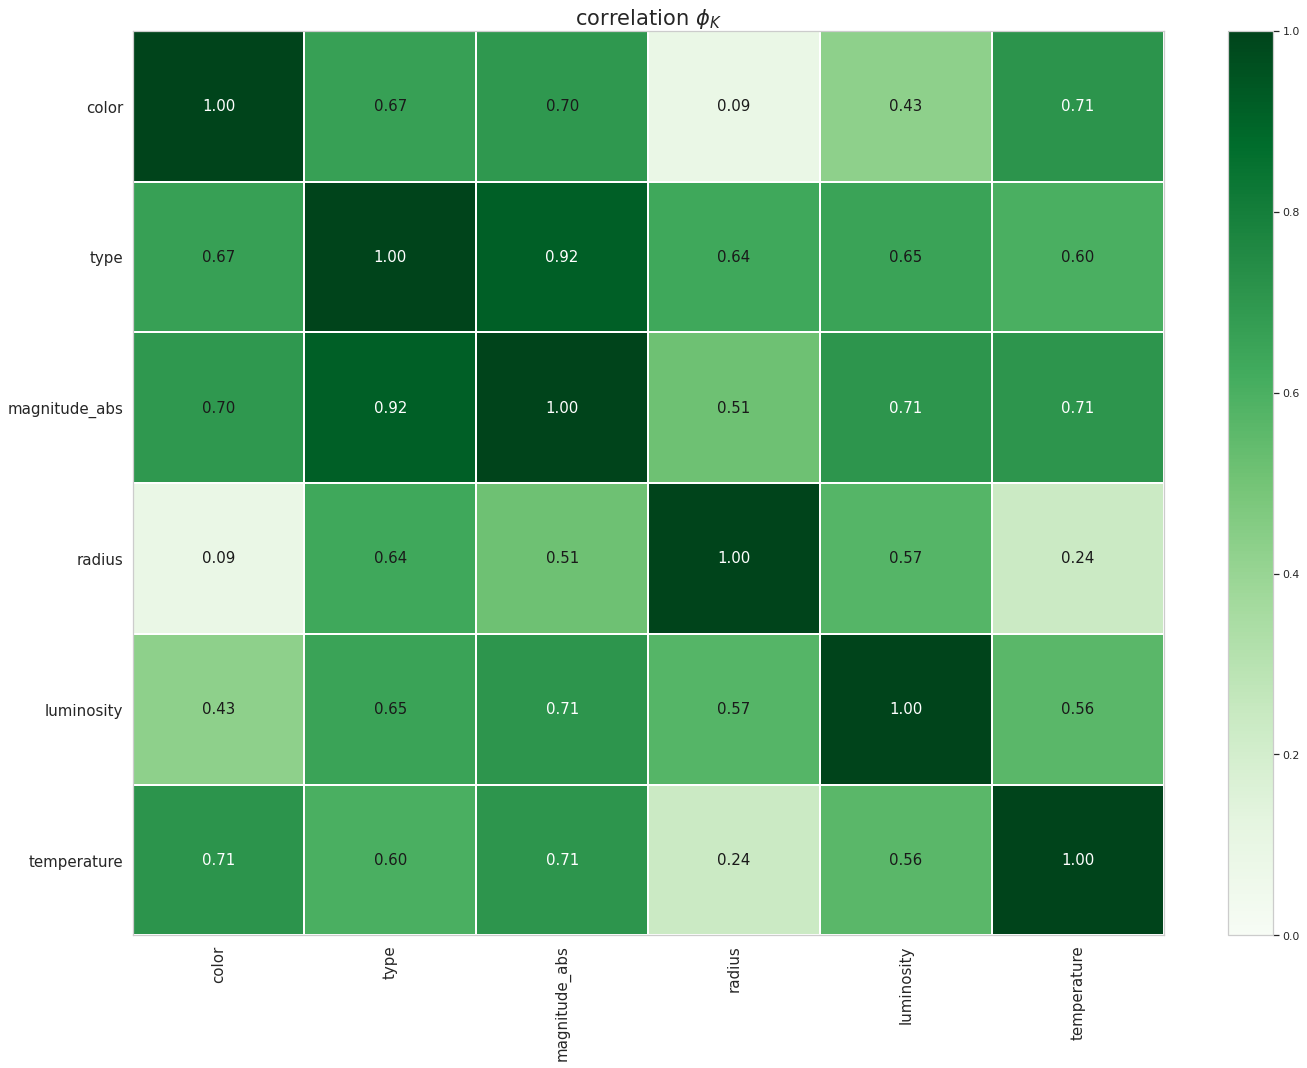

In [ ]:
# матрица корреляции
plot_correlation_matrix(
    phik_overview_new.values,
    x_labels=phik_overview_new.columns,
    y_labels=phik_overview_new.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Радиус и цвет звезды практически не имеют связи между собой. А вот в остальном все имеющиеся признаки имеют связи друк с другом и между собой и целевым признаком разной степери тесноты.

## Работа с сетью

### Подготовка данных к построению модели

Теперь надо заново определить наши категориальные и числовые признаки.

In [ ]:
# вспоминаем названия столбцов
stars_new.columns

Index(['temperature', 'luminosity', 'radius', 'magnitude_abs', 'type',
       'color'],
      dtype='object')

In [ ]:
# создаем список с числовыми признаками
num_features = ['luminosity', 'radius', 'magnitude_abs']

In [ ]:
# создаем список с категориальными признаками
cat_features = ['type', 'color']

In [ ]:
target = 'temperature' # задаем целевой признак

Отделим целевой и остальные признаки.

In [ ]:
# отделяем признаки (X)
X = stars_new.drop(columns=[target])
X.head() # проверка

,luminosity,radius,magnitude_abs,type,color
0,0.00,0.17,16.12,0,red
1,0.00,0.15,16.60,0,red
2,0.00,0.10,18.70,0,red
3,0.00,0.16,16.65,0,red
4,0.00,0.10,20.06,0,red


In [ ]:
y = stars_new[target]  # целевая переменная
pd.DataFrame(y).head() # проверка

,temperature
0,3068
1,3042
2,2600
3,2800
4,1939


Так как некоторых цветов у нас очень мало, при разбиении на выборке необходимо добавить стратификацию по данному признаку, чтобы каждый вариант попал в каждую выборку.

In [ ]:
# разделяем данные с учетом стратификации по 'color'
X_train, X_valid, y_train, y_valid = train_test_split(
                                    X, y,
                                    test_size=TEST_SIZE, # равно 0.3, прописано ранее
                                    random_state=RANDOM_STATE, # равно 42, прописано ранее
                                    shuffle=True, # перемешивание
                                    stratify=X['color']
                                        )

In [ ]:
# проверка разбиения
print(color.BLUE + color.BOLD + f"Размер X_train: "\
      + color.END + f"{X_train.shape}")
print(color.BLUE + color.BOLD + f"Размер X_valid: "\
      + color.END + f"{X_valid.shape}")
print(color.BLUE + color.BOLD + f"Размер y_train: "\
      + color.END + f"{y_train.shape}")
print(color.BLUE + color.BOLD + f"Размер y_valid: "\
      + color.END + f"{y_valid.shape}")

Размер X_train: (168, 5)
Размер X_valid: (72, 5)
Размер y_train: (168,)
Размер y_valid: (72,)


Теперь можно преобразовывать.

Попробуем сделать подготовку через пайплайн. Будем OHE для кодировки категориальных признаков. И обойдемся без скалирования целевого признака.

In [ ]:
# собираем преобразователь
col_transformer = ColumnTransformer(
                        transformers=[
                            ('scaler', StandardScaler(), num_features), # числовые
                            ('ohe', OneHotEncoder(drop='first', # избегаем дамми-ловушки
                                                  handle_unknown='ignore', # игнорируем неизвестные значения
                                                  sparse_output=False), # "сохраняем" имена
                             cat_features)], # категориальные
                                remainder="passthrough" # не изменяем неуказанные столбцы
                                  )

In [ ]:
# тренируем
col_transformer.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('scaler', StandardScaler(),
                                 ['luminosity', 'radius', 'magnitude_abs']),
                                ('ohe',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['type', 'color'])])

In [ ]:
# преобразуем тренировочные данные
X_train = col_transformer.transform(X_train)

In [ ]:
# просмотр первых строк вместе с именами
pd.DataFrame(X_train,columns = col_transformer.get_feature_names_out()).head(10)

,scaler__luminosity,scaler__radius,scaler__magnitude_abs,ohe__type_1,ohe__type_2,ohe__type_3,ohe__type_4,ohe__type_5,ohe__color_blue-white,ohe__color_orange,ohe__color_red,ohe__color_white,ohe__color_yellow,ohe__color_yellow-white
0,-0.59,-0.45,0.96,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
1,-0.59,-0.45,0.75,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2,-0.56,-0.43,-0.72,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
3,1.22,-0.28,-0.96,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,-0.58,-0.44,-0.39,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
5,-0.59,-0.45,1.18,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
6,0.32,2.08,-1.48,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00
7,0.43,2.60,-1.49,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00
8,-0.59,-0.45,1.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
9,-0.59,-0.45,0.84,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
# преобразуем валидационные
X_valid = col_transformer.transform(X_valid)
# просмотр первых строк вместе с именами
pd.DataFrame(X_valid,columns = col_transformer.get_feature_names_out()).head(10)

,scaler__luminosity,scaler__radius,scaler__magnitude_abs,ohe__type_1,ohe__type_2,ohe__type_3,ohe__type_4,ohe__type_5,ohe__color_blue-white,ohe__color_orange,ohe__color_red,ohe__color_white,ohe__color_yellow,ohe__color_yellow-white
0,-0.59,-0.44,-0.28,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
1,-0.59,-0.45,0.68,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2,1.40,2.50,-1.24,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
3,-0.59,-0.45,0.23,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
4,-0.59,-0.45,0.90,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
5,0.09,-0.40,-1.09,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,-0.55,-0.43,-0.64,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
7,-0.59,-0.45,0.74,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
8,0.69,-0.26,-1.03,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,1.20,-0.25,-1.07,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Преобразования прошли успешно.

### Построение базовой нейронной сети

Для начала необходимо получить тензоры.

In [ ]:
# преобразование выборок в тензоры
# менее явный, может привести к неожидонностям с типами данных
X_train_tensor = torch.Tensor(X_train)
X_valid_tensor  = torch.Tensor(X_valid)
y_train_tensor = torch.Tensor(y_train.values)
y_valid_tensor  = torch.Tensor(y_valid.values)

In [ ]:
# проверка размерности тензоров
for x in ['X_train_tensor', 'X_valid_tensor', 'y_train_tensor', 'y_valid_tensor']:
    print(color.BLUE + color.BOLD + f'Размерность {x}: '+ color.END + f'{globals()[x].shape}')

Размерность X_train_tensor: torch.Size([168, 14])
Размерность X_valid_tensor: torch.Size([72, 14])
Размерность y_train_tensor: torch.Size([168])
Размерность y_valid_tensor: torch.Size([72])


Зададим архитектуру сети и ее параметры. Пока обойдемся двумя слоями и без Dropout (так как нейронов возьмем немного).

In [ ]:
# cоздадим ПНС
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons, dropout_rate=0):
            super(Net, self).__init__()

            self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
            self.act1 = nn.ReLU()
            self.dp1 = nn.Dropout(p=dropout_rate)
            self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
            self.act2 = nn.LeakyReLU()
            self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)

    def forward(self, x):
        x = self.dp1(self.act1(self.fc1(x)))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
# количества нейронов
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

In [ ]:
# остальные настройки сети
net = Net(n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons) # инициализация
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3) # оптимизатор
loss = nn.MSELoss() # функция потерь

Доработаем данные для удобства оперирования ими.

In [ ]:
# "упакуем" и настроим данные для обучения
# from torch.utils.data import Dataset, DataLoader # унесено в начало, тут помечено, к чему относится

# Создаем генератор для DataLoader
data_loader_generator = torch.Generator().manual_seed(SEED)

# Создание Dataset и DataLoader
# "соединяем" данные для обучения
dataset_train = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
# "соединяем" данные для валидации
dataset_valid = torch.utils.data.TensorDataset(X_valid_tensor, y_valid_tensor)

# "загружаем" данные для обучения и задаем параметры
train_dataloader = DataLoader(dataset_train, # данные
                              batch_size=40, # размер батча
                              shuffle=True, # перемешивание данных
                              generator=data_loader_generator, # фиксация перемешивания
                              num_workers=0) # количество потоков
# повторяем для валидационных, перемешивание для валидационных данных обычно не нужно
valid_dataloader = DataLoader(dataset_valid, batch_size=40, shuffle=False, num_workers=0)

Чтобы не тратить ресурсы, необходимо остановить обучение при отсутствии улучшений. Для этого нужно прописать класс.

In [ ]:
class CustomEarlyStopping():
    """
    Ранняя остановка, чтобы остановить тренировку, когда потеря не улучшается после определенной эпохи.
    """
    def __init__(self, patience=5, min_delta=0):
        """
        :param patience: сколько эпох ждать, прежде чем остановиться, когда потеря не улучшается
        :param min_delta: минимальная разница между loss/метриками, если улучшений нет, то остановим обучение
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss == None:
            self.best_loss = val_loss
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            # reset counter if validation loss improves
            self.counter = 0
        elif self.best_loss - val_loss < self.min_delta:
            self.counter += 1
            print(f"INFO: Early stopping counter {self.counter} of {self.patience}")
            if self.counter >= self.patience:
                print('INFO: Early stopping')
                self.early_stop = True

In [ ]:
# Обучим нейросеть
early_stopping = CustomEarlyStopping(patience=5, min_delta=20)

num_epochs = 100001 # количество эпох исходное
best_rmse = float('inf')  # Инициализация лучшего RMSE
best_predicted_temp = None  # Сохраним лучшие предсказания

for epoch in range(num_epochs):
    net.train()  # Режим обучения
    for batch in train_dataloader:
        data_train, temperature_train = batch # просто выгружаем данные
        optimizer.zero_grad()

        preds = net.forward(data_train).flatten() # Предсказания

        loss_value = torch.sqrt(loss(preds, temperature_train)) # RMSE-loss
        loss_value.backward()  # Обратное распространение ошибки
        optimizer.step() # Обновление весов

    if epoch % 200 == 0:
        predicted_temp = []
        with torch.no_grad(): # Отключаем вычисление градиентов
            net.eval() # Режим оценки
            for batch in valid_dataloader:
                data_valid, temperature_valid = batch # просто выгружаем данные

                valid_preds = net.forward(data_valid).flatten() # Предсказания на валидации
                predicted_temp.append(valid_preds) # Добавляем в список
                RMSE_loss = torch.sqrt(loss(valid_preds, temperature_valid))

        # Объединяем все батчи в один тензор и преобразуем в numpy
        predicted_temp = torch.cat(predicted_temp).detach().numpy()
        # Вычисляем RMSE (используем numpy-версию y_valid)
        RMSE = mean_squared_error(y_valid_tensor.numpy(), predicted_temp, squared=False)

        # Проверяем, нужно ли остановиться
        early_stopping(RMSE)
        if early_stopping.counter == 0: # Если улучшилось
            best_rmse = RMSE
            best_predicted_temp = predicted_temp
        print(f"epoch:{epoch}, RMSE test: {RMSE}")

        # Если сработал ранний стоп
        if early_stopping.early_stop:
            print('Early Stoppning!!!'+ color.END)
            print(color.BLUE + color.BOLD + f'Best RMSE test {best_rmse}'+ color.END)
            break

epoch:0, RMSE test: 13320.2265625


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


epoch:200, RMSE test: 12054.212890625


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


epoch:400, RMSE test: 8494.8798828125


...

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


INFO: Early stopping counter 3 of 5
epoch:6800, RMSE test: 4401.4091796875


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


INFO: Early stopping counter 4 of 5
epoch:7000, RMSE test: 4370.92919921875
INFO: Early stopping counter 5 of 5
INFO: Early stopping
epoch:7200, RMSE test: 4370.34619140625
Early Stoppning!!!
Best RMSE test 4371.5673828125


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Мы уже можем наблюдать неплохие результаты: RMSE ниже требуемого порога в 4500. Построим график для визуализации.

In [ ]:
# задаем параметры
def fact_forecast(valid_preds, y_valid):
    '''Функция для визуализации качества регрессии "Факт-прогноз"'''

    y1 = valid_preds.reshape(-1)  # Прогноз (уже numpy-массив)
    y2 = y_valid.detach().numpy().reshape(-1)  # Факт
    x = np.arange(len(y1))  # Ось X

    fig, ax = plt.subplots(figsize=(18, 8))

    # Смещаем столбцы, чтобы они не перекрывались
    width = 0.4
    ax.bar(x - width/2, y2, width=width, label='Факт', alpha=0.7)
    ax.bar(x + width/2, y1, width=width, label='Прогноз', alpha=0.7)

    ax.set_title('График "Факт-прогноз"', fontsize=20)
    ax.set_xlabel('Номер звезды')
    ax.set_ylabel('Температура звезды')
    ax.legend()
    plt.show()

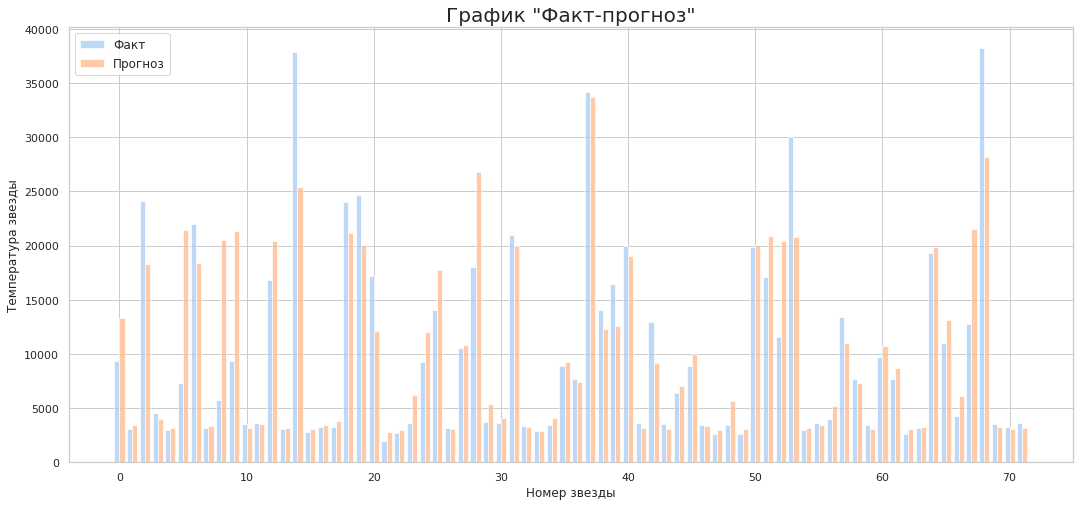

In [ ]:
# строим график
fact_forecast(predicted_temp, y_valid_tensor)

Модель уже неплохо предсказывает результаты.  Для звезд с температурой до 5 тыс К ее результаты близки к ожидаемым, а вот для более горячих она склонна как завышать, так и занижать температуры.

Возможно, ее можно улучшить?

### Улучшение нейронной сети

Пропишем некоторые классы и пременные, которые понадобятся нам в работе.

In [ ]:
# from sklearn.base import BaseEstimator - потом уехало в начало
# ранняя остановка для gs
class CustomEarlyStoppingGS(BaseEstimator, Callback):
    """
    Ранняя остановка, совместимая с GridSearchCV.
    Наследуемся от BaseEstimator для совместимости с sklearn.
    :param patience: сколько эпох ждать, прежде чем остановиться, когда потеря не улучшается
    :param min_delta: минимальная разница между loss/метриками, если улучшений нет, то остановим обучение
    """
    def __init__(self, patience=10, min_delta=20):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None

    def on_epoch_end(self, net, **kwargs):
        if 'valid_loss' not in net.history[-1]:
            return

        current_loss = net.history[-1]['valid_loss'] # Следим за валидационным loss
        if self.best_loss is None:
            self.best_loss = current_loss
        elif self.best_loss - current_loss > self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print(f"Ранняя остановка: нет улучшений {self.patience} эпох подряд")
                raise KeyboardInterrupt("Early stopping") # остановливаем обучение

In [ ]:
# вывод метрики каждые 50 эпох и в последнюю эпоху, совместимый с gs
# callback только с тренировочным RMSE
class PrintMetricsEvery50Epochs(Callback):
    def on_epoch_end(self, net, **kwargs):
        epoch = len(net.history) - 1
        if epoch % 50 == 0 or epoch == net.max_epochs-1:
            y_pred = net.predict(X_train_tensor)
            train_rmse = rmse(y_train_tensor.numpy(), y_pred)
            print(f"Epoch {epoch} | Train RMSE: {train_rmse:.4f}")

In [ ]:
# Инициализация модели с двумя callback'ами
net = NeuralNetRegressor(# класс с возможностями настройки
    module=Net, # модель
    module__n_in_neurons=n_in_neurons,
    module__n_hidden_neurons_1=n_hidden_neurons_1,
    module__n_hidden_neurons_2=n_hidden_neurons_2,
    module__n_out_neurons=n_out_neurons,
    # перемешивание тренировочных данных в каждой эпохе
    iterator_train__shuffle=True,
    optimizer=torch.optim.Adam,
    criterion=nn.MSELoss,
    max_epochs=1000, # максимальное количество эпох
    callbacks=[
        ('early_stopping', CustomEarlyStoppingGS(patience=10, min_delta=0.001)), # ранняя остановка
        ('print_metrics', PrintMetricsEvery50Epochs()), # вывод каждые 50 эпох
    ],
    verbose=0
)

In [ ]:
# параметры для GridSearch
params = {
    'batch_size': [4, 8, 16, 32, 64],
    'module__dropout_rate': [0, 0.2, 0.3],
    'optimizer__lr': [1e-3],
    'optimizer__weight_decay': [0, 1e-4],
    # Можно также оптимизировать параметры ранней остановки:
    # 'callbacks__early_stopping__patience': [5, 10],
    # 'callbacks__early_stopping__min_delta': [0.001, 0.0001]
}

In [ ]:
# Создаем объект кросс-валидации с фиксированным random_state
cv = KFold(n_splits=3, shuffle=True, random_state=SEED)

In [ ]:
# настройка GridSearch
gs = GridSearchCV(
    net, # модель
    params, # параметры
    refit=True, # переобучить лучшую модель на всех данных
    cv=cv,  # передаем объект кросс-валидации вместо числа
    scoring=rmse_scorer, # метрика
    verbose=2,  # вывод отладочной информации
#    n_jobs=-1, # использовать все ядра процессора
    n_jobs=1 # для воспроизводимости лучше использовать 1 ядро
)

In [ ]:
# Дополнительная фиксация случайности перед обучением
def reset_seed():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

reset_seed() # нужно перед каждым GridResearch/RandomSearch или ручным перебором

In [ ]:
# обучение
# .reshape(-1, 1) - чтобы избежать ошибки, если y_train окажется одномерным тензором, для двумерного ничего не изменится
gs.fit(X_train_tensor, y_train_tensor.reshape(-1, 1))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Epoch 0 | Train RMSE: 14532.5088
Epoch 50 | Train RMSE: 13856.3379
Epoch 100 | Train RMSE: 11135.6807
Epoch 150 | Train RMSE: 8448.9932
Epoch 200 | Train RMSE: 7372.3564
Epoch 250 | Train RMSE: 7104.8799
Epoch 300 | Train RMSE: 6949.0352
Epoch 350 | Train RMSE: 6807.4658
Epoch 400 | Train RMSE: 6673.3945
Epoch 450 | Train RMSE: 6535.8506
Epoch 500 | Train RMSE: 6419.5933
Epoch 550 | Train RMSE: 6325.6792
Epoch 600 | Train RMSE: 6217.3369
Epoch 650 | Train RMSE: 6125.8081
Epoch 700 | Train RMSE: 6033.3535
Epoch 750 | Train RMSE: 5969.2070
Epoch 800 | Train RMSE: 5895.7593
Epoch 850 | Train RMSE: 5840.6235
Epoch 900 | Train RMSE: 5770.3032
Epoch 950 | Train RMSE: 5721.9014
Epoch 999 | Train RMSE: 5674.1211
[CV] END batch_size=4, module__dropout_rate=0, optimizer__lr=0.001, optimizer__weight_decay=0; total time=  27.6s
Epoch 0 | Train RMSE: 14532.1963
Epoch 50 | Train RMSE: 13716.1768
Epoch 100 | Train RMSE: 10817.7471
Epoch 150

GridSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
             estimator=NeuralNetRegressor(_params_to_validate={'module__n_in_neurons', 'iterator_train__shuffle', 'module__n_hidden_neurons_2', 'module__n_hidden_neurons_1', 'module__n_out_neurons'}, batch_size=128, callbacks=[('early_stopping', CustomEarlyStoppingGS(min_delta=0.001)), ('print_metrics', <__m...rgs=None, train_split=<skorch.dataset.ValidSplit object at 0x7f822f4fc580>, use_caching='auto', verbose=0, warm_start=False),
             n_jobs=1,
             param_grid={'batch_size': [4, 8, 16, 32, 64],
                         'module__dropout_rate': [0, 0.2, 0.3],
                         'optimizer__lr': [0.001],
                         'optimizer__weight_decay': [0, 0.0001]},
             scoring=make_scorer(rmse, greater_is_better=False, response_method='predict'),
             verbose=2)

Как мы видим, модель лучше не стала.

In [ ]:
# вывод результатов
print(color.BLUE + color.BOLD + f"\nЛучшие параметры:"+ color.END)
for param, value in gs.best_params_.items():
    print(f"{param:>20}: {value}")

print(color.BLUE + color.BOLD + f"\nЛучший RMSE: "+ color.END + f"{-gs.best_score_:.4f}")


Лучшие параметры:
          batch_size: 4
module__dropout_rate: 0
       optimizer__lr: 0.001
optimizer__weight_decay: 0.0001

Лучший RMSE: 6658.6239


Лучшие параметры для сети найдены. И метрика у нее хуже, чем у базовой.

In [ ]:
# сохранение лучшей модели из GridSearch
best_model = gs.best_estimator_

In [ ]:
# получаем предсказания (уже в numpy-формате)
y_pred = best_model.predict(X_valid_tensor.numpy())  # X_valid должен быть тензором

In [ ]:
# создаем DataFrame для сравнения
results = pd.DataFrame({
    'Факт': y_valid_tensor.numpy().reshape(-1, 1).flatten(),
    'Прогноз': y_pred.flatten()
}, index=range(len(y_valid_tensor.numpy().reshape(-1, 1))))

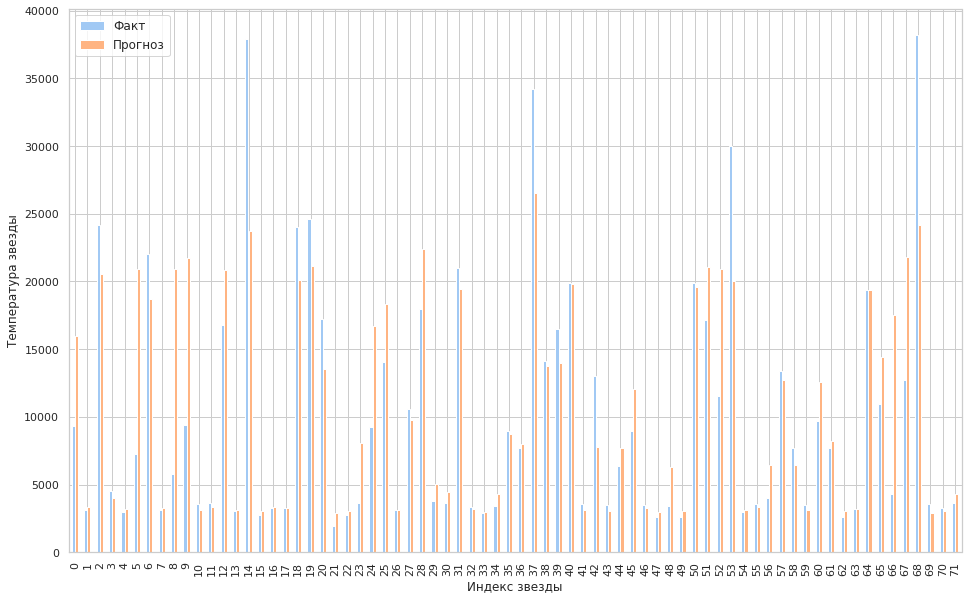

In [ ]:
# график
results.plot(kind='bar',figsize=(16,10))
plt.xlabel('Индекс звезды')
plt.ylabel('Температура звезды')
plt.show()

In [ ]:
# получаем предсказания (уже в numpy-формате)
y_pred = best_model.predict(X_valid_tensor.numpy())  # X_valid должен быть тензором

In [ ]:
# создаем DataFrame для сравнения
results = pd.DataFrame({
    'Факт': y_valid_tensor.numpy().reshape(-1, 1).flatten(),
    'Прогноз': y_pred.flatten()
}, index=range(len(y_valid_tensor.numpy().reshape(-1, 1))))

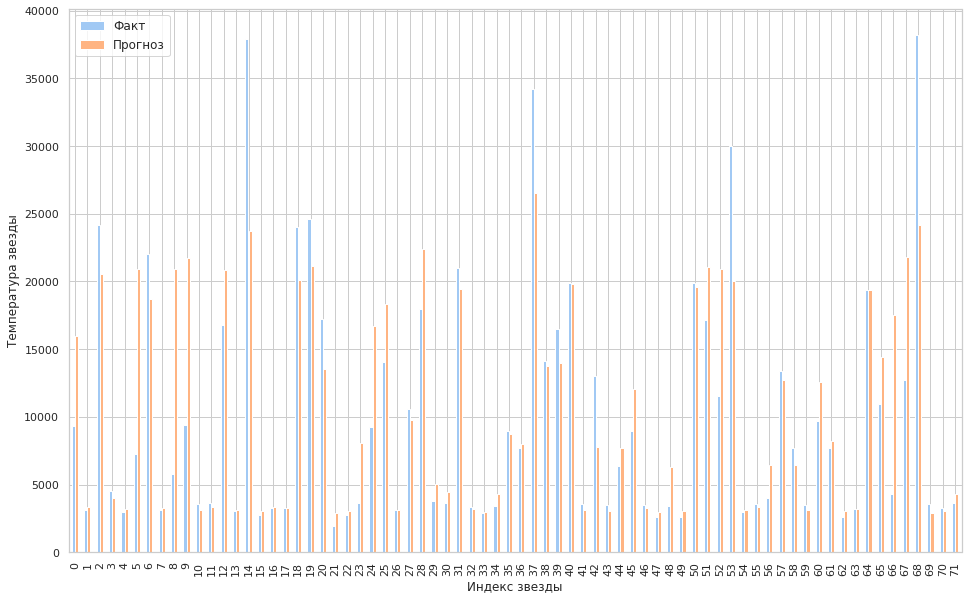

In [ ]:
# график
results.plot(kind='bar',figsize=(16,10))
plt.xlabel('Индекс звезды')
plt.ylabel('Температура звезды')
plt.show()

Данная модель склонна завышать температуру некотрым звездам "среднего диапазона температур" и занижать крайне горячим и крайне холодным. То есть модель стала хуже предсказывать и на диапазоне до 5 тыс К.

**Вывод**

- Изменение способа предобработки данных и изменение функции активации позволили создать baseline модель, чей RMSE оказался меньше порога в 4500.
- Изменение вероятности выключения нейронов и размера батчей ухудшили модель.

## Выводы

- Мы имеем всего 240 объектов. Часть из них имеет аномально высокую температуру. Поэтому правильный подход к обработке информации для работы с моделью очень важен.
- Мы провели множество попыток с разными способами обработки данных и функциями активаций, прежде чем получить необходимую метрику.
- Получившиеся в итоге два варианта baseline модели оказались с несложной архитектурой и не очень большим количеством нейронов. Однако поиск данных конфигурации занял много времени. Для звезд с температурой до 5 тыс К предсказания данных сетей близки к ожидаемым, а вот для более горячих они склонны как завышать, так и занижать температуры.
- Улучшить данные сеть не получилось, выключение нейронов (которых и так немного) и изменение размера батча приводили лишь к ухудшению параметров.
- Так как данные табличные, возможно классическое машинное обучение было бы использовать предпочтительней (тем более, что у сетей часто страдает воспроизводимость результатов).
- Для улучшения модели необходимы дальнейшие эксперименты и больше данных.